# ROC Curve Comparison Notebook
This notebook version of your `.py` script allows interactive execution
of ROC curve comparison for individual and ensemble models.

In [1]:
# ===========================================================
# One-shot data copy — run this once on the cluster, then rsync
# `/projects/retprogression/ROC_data` to your laptop. Mirrors the
# path layout under `/projects/retprogression/` so you can later
# change a single base prefix to point the notebook at the copy.
# ===========================================================
import os, shutil, glob
from pathlib import Path

SRC_ROOT = Path("/projects/retprogression")
DST_ROOT = Path("/projects/retprogression/rgarridogarcia/ROC_data")

# Each entry can be a single file path, a glob pattern (str with *), or a
# directory (recursively copies all .csv files under it). Anything outside
# SRC_ROOT is placed at the top level of DST_ROOT.
SOURCES = [
    # Single files
    "/projects/retprogression/gradable_dr_new_5k_clean_test.csv",
    "/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv",
    # Ensemble outputs (calibration + validation halves)
    "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_*.csv",
    "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_*.csv",
    # Per-model predictions on each half
    "/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv",
    "/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv",
    # DR-folded directories (recursive — pulls predictions_best_balanced_acc_model.csv etc.)
    "/projects/retprogression/rgarridogarcia/gradable_dr_test",
    "/projects/retprogression/rgarridogarcia/gradable_dr_val",
]

def _dst_for(src_path: Path) -> Path:
    """Mirror `src_path` under DST_ROOT, preserving the path relative to SRC_ROOT."""
    try:
        rel = src_path.resolve().relative_to(SRC_ROOT)
    except ValueError:
        rel = Path(src_path.name)
    return DST_ROOT / rel

def _copy_file(src_path: Path) -> Path:
    dst = _dst_for(src_path)
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, dst)
    return dst

n_copied = 0
missing  = []

for src in SOURCES:
    sp = Path(src)
    if sp.is_dir():
        for root, _, files in os.walk(sp):
            for f in files:
                if f.endswith(".csv"):
                    _copy_file(Path(root) / f)
                    n_copied += 1
        continue
    if "*" in src:
        matches = glob.glob(src)
        if not matches:
            missing.append(src); continue
        for m in matches:
            _copy_file(Path(m))
            n_copied += 1
        continue
    if not sp.exists():
        missing.append(src); continue
    _copy_file(sp)
    n_copied += 1

print(f"Copied {n_copied} files to {DST_ROOT}")
if missing:
    print(f"\n{len(missing)} missing sources (skipped):")
    for m in missing:
        print(f"  {m}")

print("\nNext step — bundle and download to your laptop, on the cluster:")
print(f"  tar czf ROC_data.tar.gz -C {DST_ROOT.parent} {DST_ROOT.name}")
print("  scp <cluster>:ROC_data.tar.gz ./   # then `tar xzf ROC_data.tar.gz`")
print("\nLocally, point the notebook at the copy by replacing the path prefix,")
print('e.g.  SRC_PREFIX = "/path/to/ROC_data"  and prepend it to every "/projects/retprogression/..." in the rest of the notebook.')


Copied 70 files to /projects/retprogression/rgarridogarcia/ROC_data

Next step — bundle and download to your laptop, on the cluster:
  tar czf ROC_data.tar.gz -C /projects/retprogression/rgarridogarcia ROC_data
  scp <cluster>:ROC_data.tar.gz ./   # then `tar xzf ROC_data.tar.gz`

Locally, point the notebook at the copy by replacing the path prefix,
e.g.  SRC_PREFIX = "/path/to/ROC_data"  and prepend it to every "/projects/retprogression/..." in the rest of the notebook.


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Optional: adjust project path manually
# sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..'))

plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
ensemble_files = glob.glob("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_*.csv")
ensemble_files

['/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_comparison.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_confidence.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_logit.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_60.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_80.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_max_confidence.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_median.csv',
 '/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_unanimous.csv']

In [4]:
df = pd.read_csv("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv")
print(df.head())
print("Unique y_prob_pos values:", df["y_prob_pos"].unique()[:20])
print("Number of unique values:", len(df["y_prob_pos"].unique()))
print("Number of unique values:", len(df["y_true"].unique()))

       id  y_true  y_prob_pos  y_pred  n_folds  std_prob
0  605367       0    0.963294       1        5  0.024629
1  605394       1    0.993335       1        5  0.002314
2  605395       1    0.990095       1        5  0.004949
3  605397       1    0.990321       1        5  0.004385
4  605539       1    0.988245       1        5  0.007091
Unique y_prob_pos values: [0.96329358 0.99333456 0.99009473 0.99032142 0.98824513 0.82263622
 0.99555569 0.94529595 0.97756826 0.97323542 0.99043292 0.99629062
 0.98967254 0.94706686 0.90730487 0.78640599 0.99142276 0.98231539
 0.97555593 0.97786661]
Number of unique values: 825
Number of unique values: 2


In [5]:
print("Positives:", sum(df.y_true == 1))
print("Negatives:", sum(df.y_true == 0))
print("Total:", len(df))
print("Positive rate:", sum(df.y_true == 1) / len(df))

Positives: 806
Negatives: 19
Total: 825
Positive rate: 0.9769696969696969


In [6]:
df = pd.read_csv("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv")

from sklearn.metrics import roc_curve, roc_auc_score

def load_predictions(file_path):
    df = pd.read_csv(file_path)  # or whatever format you're using
    y_true = df['y_true'].values  # adjust column names
    y_prob = df['y_prob_pos'].values
    return y_true, y_prob

y_true_ens, y_prob_ens = load_predictions("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv")

print(y_true_ens, y_prob_ens)
print(np.unique(y_true_ens))
fpr_ens, tpr_ens, _ = roc_curve(y_true_ens, y_prob_ens)
auc_ens = roc_auc_score(y_true_ens, y_prob_ens)


[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

In [14]:
print("AUC (ensemble_average):", auc_ens)
print(fpr_ens, tpr_ens)

AUC (ensemble_average): 0.9282356014104741
[0.         0.         0.         0.05263158 0.05263158 0.10526316
 0.10526316 0.15789474 0.15789474 0.21052632 0.21052632 0.26315789
 0.26315789 0.36842105 0.36842105 0.42105263 0.42105263 0.52631579
 0.52631579 0.68421053 0.68421053 0.73684211 0.73684211 0.78947368
 0.78947368 0.94736842 0.94736842 1.        ] [0.         0.00124069 0.48014888 0.48014888 0.60545906 0.60545906
 0.82506203 0.82506203 0.87468983 0.87468983 0.96153846 0.96153846
 0.97766749 0.97766749 0.97890819 0.97890819 0.99007444 0.99007444
 0.99503722 0.99503722 0.99627792 0.99627792 0.99751861 0.99751861
 0.99875931 0.99875931 1.         1.        ]


AUC (swapped classes): 0.9282


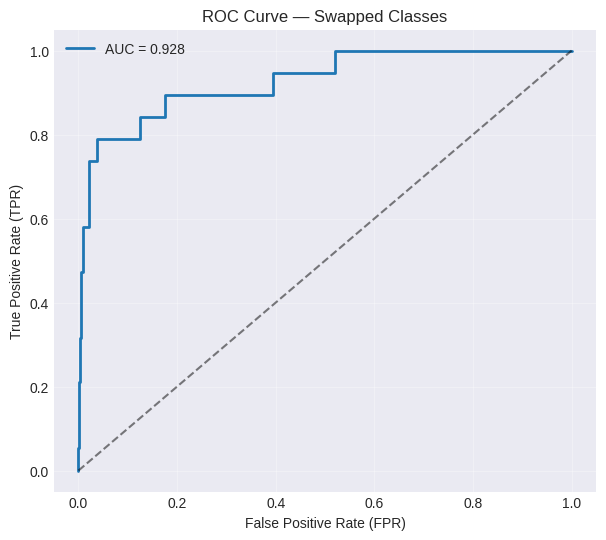

In [15]:
y_true_ens, y_prob_ens = load_predictions("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv")

# ==== INVERT CLASSES ====
y_true_swapped = 1 - y_true_ens           # swap 0 ↔ 1
y_prob_swapped = 1 - y_prob_ens           # now P(new_pos) = P(old_neg)

from sklearn.metrics import roc_curve, roc_auc_score

fpr_swapped, tpr_swapped, thresholds_swapped = roc_curve(y_true_swapped, y_prob_swapped)
auc_swapped = roc_auc_score(y_true_swapped, y_prob_swapped)

print(f"AUC (swapped classes): {auc_swapped:.4f}")

plt.figure(figsize=(7,6))
plt.plot(fpr_swapped, tpr_swapped, label=f"AUC = {auc_swapped:.3f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — Swapped Classes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
def load_predictions(file_path, type_model = 'single'):
    df = pd.read_csv(file_path)  # or whatever format you're using
    if type_model == 'single':
        y_true = df['true_label'].values  # adjust column names
        y_prob = df['prob_class_1'].values
    elif type_model == 'ensemble':
        y_true = df['y_true'].values  # adjust column names
        y_prob = df['y_prob_pos'].values
    return y_true, y_prob

Found individual models: 5
Valid ensemble prediction files: 8
  - ensemble_average.csv
  - ensemble_confidence.csv
  - ensemble_logit.csv
  - ensemble_majority_60.csv
  - ensemble_majority_80.csv
  - ensemble_max_confidence.csv
  - ensemble_median.csv
  - ensemble_unanimous.csv
Individual Models
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_confidence.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_logit.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_60.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_80.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_max_confidence.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_

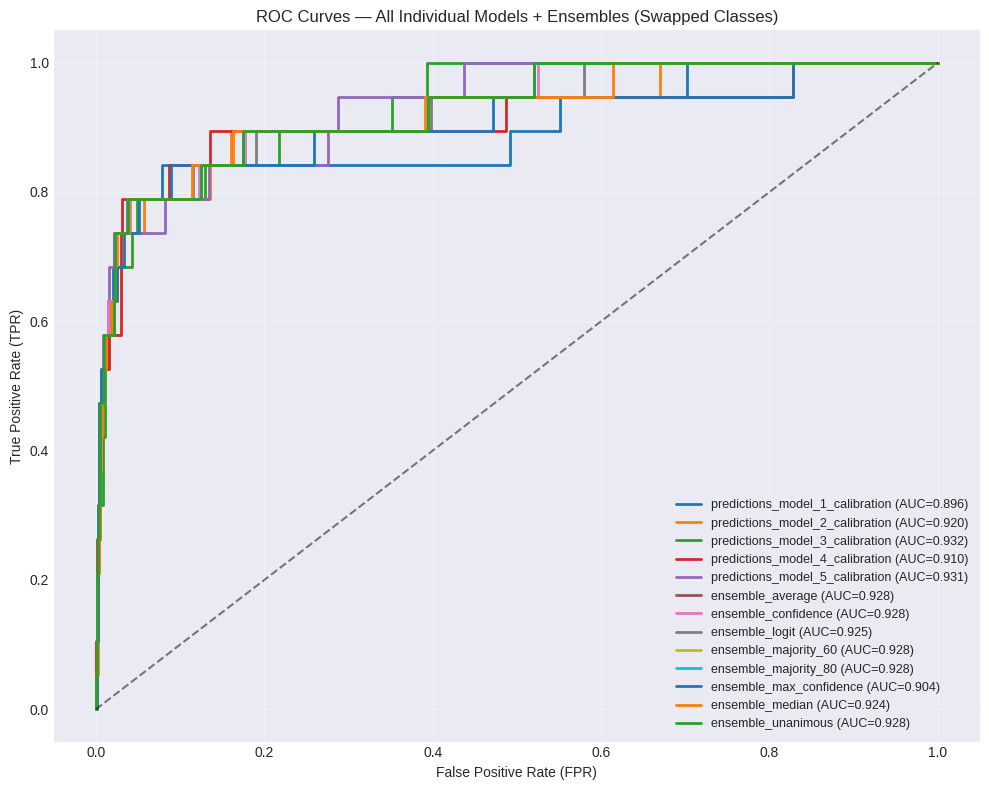

In [17]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ===========================================================
# 1. GET ALL INDIVIDUAL MODEL PREDICTION FILES
# ===========================================================
individual_cal_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv")
)

print("Found individual models:", len(individual_cal_files))


# ===========================================================
# 2. GET ONLY VALID ENSEMBLE PREDICTION FILES
#    (exclude summary files, threshold files, analysis files)
# ===========================================================
ensemble_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split"

all_ensemble_files = glob.glob(os.path.join(ensemble_dir, "ensemble_*.csv"))

ensemble_cal_files = []
for f in all_ensemble_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_cal_files.append(f)

print("Valid ensemble prediction files:", len(ensemble_cal_files))
for f in ensemble_cal_files:
    print("  -", os.path.basename(f))


# ===========================================================
# 3. PLOT SETUP
# ===========================================================
plt.figure(figsize=(10, 8))


# ===========================================================
# 4. MODEL PLOTTING FUNCTION
# ===========================================================
def plot_model(file_path, color=None, type_model = 'single'):
    name = os.path.basename(file_path).replace(".csv", "")

    # Load model predictions
    y_true, y_prob = load_predictions(file_path, type_model = type_model)

    # ==== INVERT CLASSES ====
    y_true = 1 - y_true
    y_prob = 1 - y_prob

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    # Plot curve
    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC={auc:.3f})",
        linewidth=2
    )

    return auc


# ===========================================================
# 5. PLOT ALL INDIVIDUAL MODELS
# ===========================================================
print('Individual Models')
for f in individual_cal_files:
    plot_model(f, type_model = 'single')


# ===========================================================
# 6. PLOT ALL ENSEMBLES
# ===========================================================
for f in ensemble_cal_files:
    print(f)
    plot_model(f, type_model = 'ensemble')
print('Ensembles')


# ===========================================================
# 7. RANDOM BASELINE
# ===========================================================
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)


# ===========================================================
# 8. FINAL PLOT FORMATTING
# ===========================================================
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves — All Individual Models + Ensembles (Swapped Classes)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Found individual validation models: 5
Valid ensemble validation prediction files: 8
  - ensemble_average.csv
  - ensemble_confidence.csv
  - ensemble_logit.csv
  - ensemble_majority_60.csv
  - ensemble_majority_80.csv
  - ensemble_max_confidence.csv
  - ensemble_median.csv
  - ensemble_unanimous.csv
Individual Models
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_confidence.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_logit.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_60.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_majority_80.csv
/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_max_confidence.csv
/projects/retprogression/rgarridogarcia/ensemble/ense

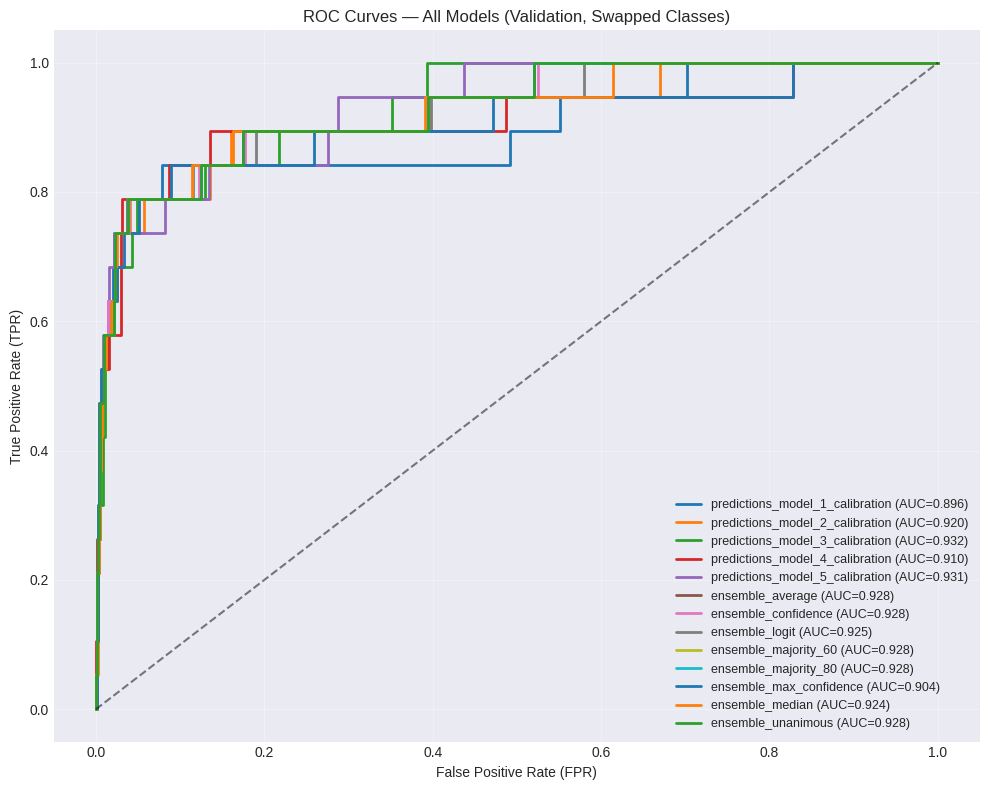

In [18]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ===========================================================
# 1. GET ALL INDIVIDUAL VALIDATION MODEL FILES
# ===========================================================
individual_val_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv")
)

print("Found individual validation models:", len(individual_val_files))


# ===========================================================
# 2. GET ONLY VALID ENSEMBLE PREDICTION FILES (VALIDATION)
# ===========================================================
ensemble_val_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split"

all_ensemble_val_files = glob.glob(os.path.join(ensemble_val_dir, "ensemble_*.csv"))

ensemble_val_files = []
for f in all_ensemble_val_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_val_files.append(f)

print("Valid ensemble validation prediction files:", len(ensemble_val_files))
for f in ensemble_val_files:
    print("  -", os.path.basename(f))


# ===========================================================
# 3. PLOT SETUP
# ===========================================================
plt.figure(figsize=(10, 8))


# ===========================================================
# 4. MODEL PLOTTING FUNCTION
# ===========================================================
def plot_model(file_path, color=None, type_model = 'single'):
    name = os.path.basename(file_path).replace(".csv", "")

    # Load model predictions
    y_true, y_prob = load_predictions(file_path, type_model = type_model)

    # ==== INVERT CLASSES ====
    y_true = 1 - y_true
    y_prob = 1 - y_prob

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    # Plot curve
    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC={auc:.3f})",
        linewidth=2
    )

    return auc


# ===========================================================
# 5. PLOT ALL INDIVIDUAL MODELS
# ===========================================================
print('Individual Models')
for f in individual_cal_files:
    plot_model(f, type_model = 'single')


# ===========================================================
# 6. PLOT ALL ENSEMBLES
# ===========================================================
for f in ensemble_cal_files:
    print(f)
    plot_model(f, type_model = 'ensemble')
print('Ensembles')


# ===========================================================
# 7. RANDOM BASELINE
# ===========================================================
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)


# ===========================================================
# 8. FINAL PLOT FORMATTING
# ===========================================================
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves — All Models (Validation, Swapped Classes)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Using individual model file(s):
  - predictions_model_5_calibration.csv

Using ensemble files:
  - ensemble_average.csv
  - ensemble_logit.csv


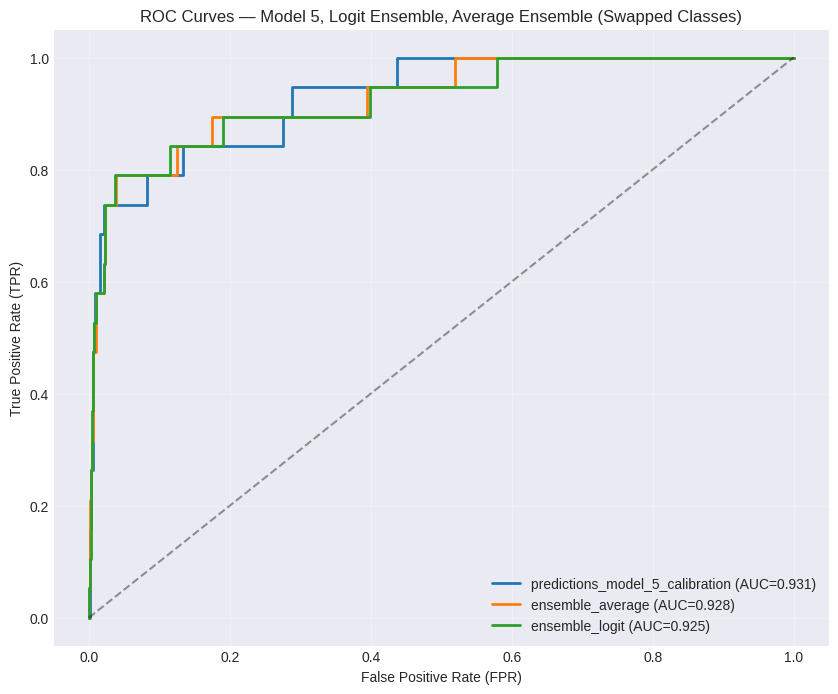

In [19]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ===========================================================
# KEEP ONLY INDIVIDUAL MODEL 5
# ===========================================================
individual_cal_files = [
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv")
    if "predictions_model_5_" in f
]

print("Using individual model file(s):")
for f in individual_cal_files:
    print("  -", os.path.basename(f))

# ===========================================================
# KEEP ONLY LOGIT + AVERAGE ENSEMBLES
# ===========================================================
ensemble_cal_files = [
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_*.csv")
    if ("ensemble_logit.csv" in f) or ("ensemble_average.csv" in f)
]

print("\nUsing ensemble files:")
for f in ensemble_cal_files:
    print("  -", os.path.basename(f))

# ===========================================================
# PLOT SETUP
# ===========================================================
plt.figure(figsize=(10, 8))

def plot_model(file_path, color=None, type_model = 'single'):
    name = os.path.basename(file_path).replace(".csv", "")

    # Load model predictions
    y_true, y_prob = load_predictions(file_path, type_model = type_model)

    # Invert classes
    y_true = 1 - y_true
    y_prob = 1 - y_prob

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

# Plot model 5
for f in individual_cal_files:
    plot_model(f, type_model = 'single')

# Plot logit + average ensembles
for f in ensemble_cal_files:
    plot_model(f, type_model = 'ensemble')

# Baseline
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves — Model 5, Logit Ensemble, Average Ensemble (Swapped Classes)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Using individual validation model:
  - predictions_model_5_validation.csv

Using ensemble validation file:
  - ensemble_average.csv


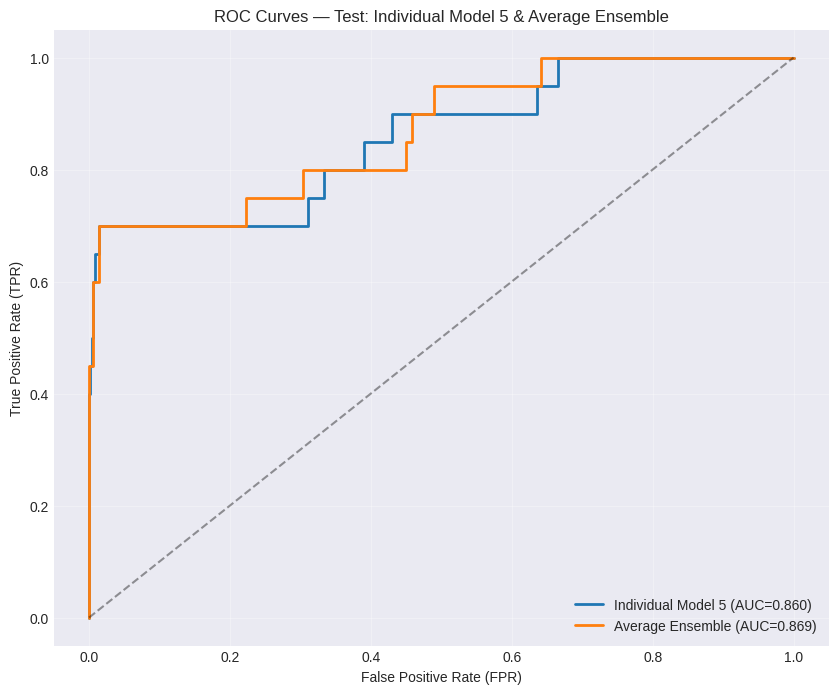

In [20]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ===========================================================
# KEEP ONLY INDIVIDUAL MODEL 5 (VALIDATION)
# ===========================================================
individual_val_files = [
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv")
    if "predictions_model_5_" in f
]

print("Using individual validation model:")
for f in individual_val_files:
    print("  -", os.path.basename(f))

# ===========================================================
# KEEP ONLY AVERAGE ENSEMBLE (VALIDATION)
# ===========================================================
ensemble_val_files = [
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_*.csv")
    if "ensemble_average.csv" in f
]

print("\nUsing ensemble validation file:")
for f in ensemble_val_files:
    print("  -", os.path.basename(f))


# ===========================================================
# PLOT SETUP
# ===========================================================
plt.figure(figsize=(10, 8))

def plot_model(file_path):
    fname = os.path.basename(file_path)

    # Assign clean display names
    if "predictions_model_5" in fname:
        name = "Individual Model 5"
        # Load predictions
        y_true, y_prob = load_predictions(file_path, type_model = 'single')
    elif "ensemble_average" in fname:
        name = "Average Ensemble"
        # Load predictions
        y_true, y_prob = load_predictions(file_path, type_model = 'ensemble')
    else:
        name = fname.replace(".csv", "")

    

    # Invert classes
    y_true = 1 - y_true
    y_prob = 1 - y_prob

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")


# ===========================================================
# PLOT MODELS
# ===========================================================
for f in individual_val_files:
    plot_model(f)

for f in ensemble_val_files:
    plot_model(f)

# ===========================================================
# BASELINE
# ===========================================================
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

# ===========================================================
# LABELING & FORMATTING
# ===========================================================
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves — Test: Individual Model 5 & Average Ensemble")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Uncorrected ROC Curves Test1 and Test2

single 825
single 826
single 825
single 826
single 825
single 826
single 825
single 826
single 825
single 826
ensemble 825
ensemble 826
single 825
single 826
single 825
single 826
single 825
single 826
single 825
single 826
single 825
single 826
ensemble 825
ensemble 826


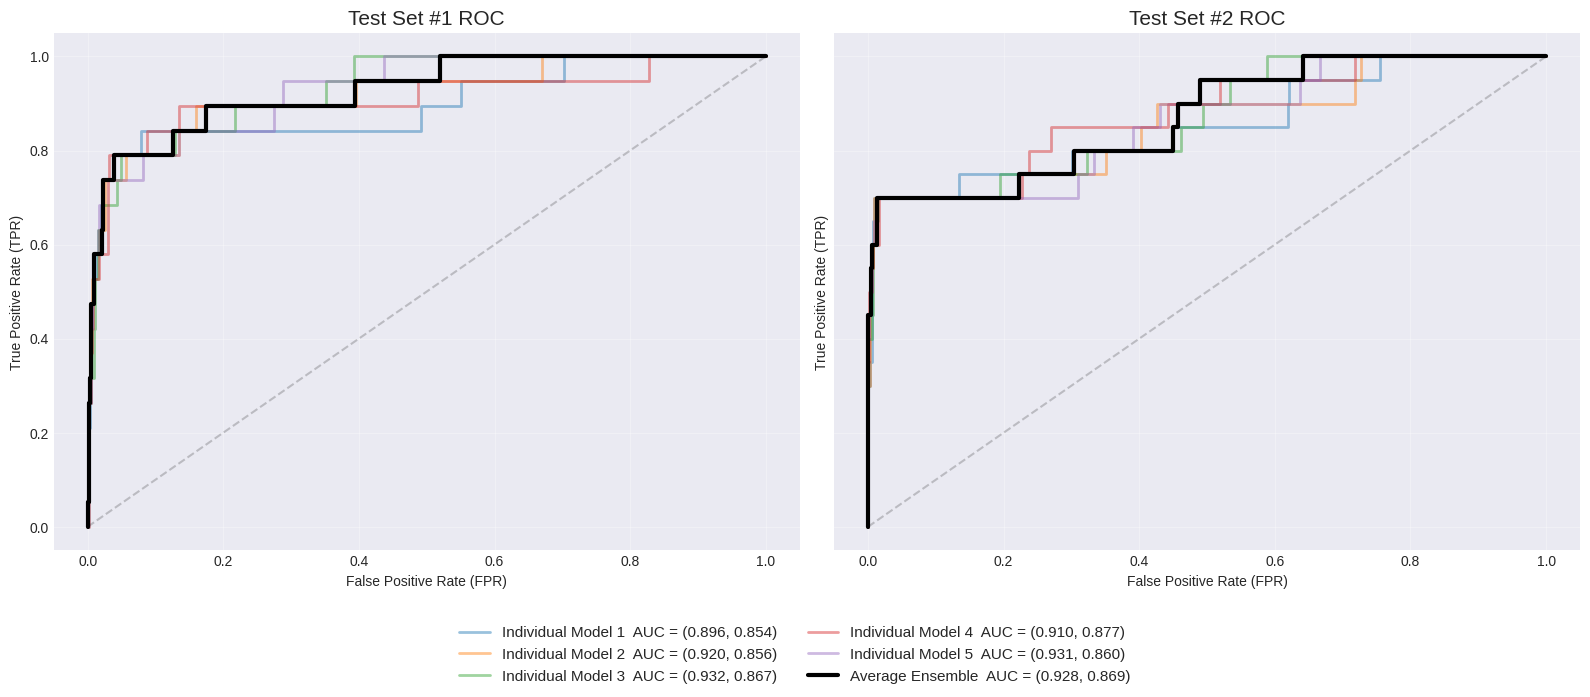

In [8]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ===========================================================
# Helper: Load and invert classes
# ===========================================================
def load_and_invert(file_path, type_model = 'single'):
    
    y_true, y_prob = load_predictions(file_path, type_model = type_model)
    y_true = 1 - y_true    # invert class labels
    y_prob = 1 - y_prob    # invert probabilities
    print(type_model, len(y_true))
    return y_true, y_prob


# ===========================================================
# 1. FILE LISTS — INDIVIDUAL MODELS 1–5 + AVERAGE ENSEMBLE
# ===========================================================

# ------ Calibration ------
individual_cal_files = sorted(
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv")
    if any(f"predictions_model_{i}_" in f for i in range(1, 6))
)
ensemble_cal_file = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv"

# ------ Test / Validation ------
individual_test_files = sorted(
    f for f in glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv")
    if any(f"predictions_model_{i}_" in f for i in range(1, 6))
)
ensemble_test_file = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_average.csv"


# ===========================================================
# 2. SETUP FIGURE — 1 row, 2 columns
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
ax_cal, ax_test = axes


# ===========================================================
# 3. STORE AUC VALUES FOR LEGEND SUMMARY
# ===========================================================
auc_table = {}    # key = "Model 1", value = (cal_auc, test_auc)


# ===========================================================
# 4. Helper to compute ROC + AUC
# ===========================================================
def compute_auc_for_file(file_path, type_model = 'single'):
    """Return fpr, tpr, AUC for an inverted file."""
    y_true, y_prob = load_and_invert(file_path, type_model = type_model)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    return fpr, tpr, auc


# ===========================================================
# 5. PLOT CURVES FOR BOTH PANELS
# ===========================================================
def plot_group(ax, cal_files, test_files, ensemble_cal, ensemble_test, title):
    
    plt.style.use("seaborn-v0_8-darkgrid")

    handles = []
    labels = []

    # ---- Plot Individual Models 1–5 ----
    for i in range(5):
        model_num = i + 1
        # Find correct files
        cal_file = [f for f in cal_files if f"predictions_model_{model_num}_" in f][0]
        test_file = [f for f in test_files if f"predictions_model_{model_num}_" in f][0]

        # Compute ROC for both sets
        fpr_c, tpr_c, auc_c = compute_auc_for_file(cal_file, type_model = 'single')
        fpr_t, tpr_t, auc_t = compute_auc_for_file(test_file, type_model = 'single')

        # Save AUC pair
        auc_table[f"Individual Model {model_num}"] = (auc_c, auc_t)

        # Plot Calibration or Test and capture the line
        if ax is ax_cal:
            line, = ax.plot(fpr_c, tpr_c, alpha=0.45, linewidth=2)
        else:
            line, = ax.plot(fpr_t, tpr_t, alpha=0.45, linewidth=2)
        
        # Store the actual line handle and label
        handles.append(line)
        labels.append(f"Individual Model {model_num}  AUC = ({auc_c:.3f}, {auc_t:.3f})")

    # ---- Plot Average Ensemble (bold black) ----
    fpr_c_e, tpr_c_e, auc_c_e = compute_auc_for_file(ensemble_cal, type_model = 'ensemble')
    fpr_t_e, tpr_t_e, auc_t_e = compute_auc_for_file(ensemble_test, type_model = 'ensemble')

    auc_table["Average Ensemble"] = (auc_c_e, auc_t_e)

    if ax is ax_cal:
        line, = ax.plot(fpr_c_e, tpr_c_e, color="black", linewidth=3)
    else:
        line, = ax.plot(fpr_t_e, tpr_t_e, color="black", linewidth=3)
    
    handles.append(line)
    labels.append(f"Average Ensemble  AUC = ({auc_c_e:.3f}, {auc_t_e:.3f})")

    # ---- Random Baseline ----
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2)

    # ---- Labels ----
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.grid(True, alpha=0.3)
    
    return handles, labels

# ===========================================================
# 6. PRODUCE BOTH SUBPLOTS
# ===========================================================
handles_cal, labels_cal = plot_group(ax_cal, individual_cal_files, individual_test_files,
                                     ensemble_cal_file, ensemble_test_file,
                                     "Test Set #1 ROC")

handles_test, labels_test = plot_group(ax_test, individual_cal_files, individual_test_files,
                                       ensemble_cal_file, ensemble_test_file,
                                       "Test Set #2 ROC")


# ===========================================================
# 7. BUILD ONE SHARED LEGEND WITH ACTUAL LINE COLORS
# ===========================================================
# Use handles from calibration plot (colors match because same order)
fig.legend(handles_cal, labels_cal,
           loc="lower center",
           ncol=2,
           fontsize=11,
           frameon=False)


plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score

def load_predictions(file_path, type_model='single'):
    df = pd.read_csv(file_path)
    
    # Handle ensemble files (y_true, y_prob_pos)
    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values
        y_prob = df['y_prob_pos'].values
    
    # Handle individual model files (true_label, prob_class_1)
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values
        y_prob = df['prob_class_1'].values
    
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")
    
    return y_true, y_prob


def compute_metrics(file_path, threshold=0.5, type_model='single'):
    """Compute all metrics for inverted classes."""
    y_true, y_prob = load_and_invert(file_path, type_model=type_model)
    
    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    
    return {
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1': f1,
        'AUC': auc,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    }


# ===========================================================
# CREATE CALIBRATION TABLE
# ===========================================================
cal_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_cal_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single')
    metrics['Model'] = f'Model {i}'
    cal_rows.append(metrics)

# Average ensemble
metrics = compute_metrics(ensemble_cal_file, threshold=0.5, type_model='ensemble')
metrics['Model'] = 'Average Ensemble'
cal_rows.append(metrics)

# Create DataFrame
cal_table = pd.DataFrame(cal_rows)
cal_table = cal_table[['Model', 'Sensitivity', 'Specificity', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]


# ===========================================================
# CREATE VALIDATION/TEST TABLE
# ===========================================================
test_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_test_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single')
    metrics['Model'] = f'Model {i}'
    test_rows.append(metrics)

# Average ensemble
metrics = compute_metrics(ensemble_test_file, threshold=0.5, type_model='ensemble')
metrics['Model'] = 'Average Ensemble'
test_rows.append(metrics)

# Create DataFrame
test_table = pd.DataFrame(test_rows)
test_table = test_table[['Model', 'Sensitivity', 'Specificity', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]


# ===========================================================
# DISPLAY TABLES
# ===========================================================
print("="*80)
print("CALIBRATION PERIOD METRICS")
print("="*80)
display(cal_table)

print("\n" + "="*80)
print("VALIDATION/TEST PERIOD METRICS")
print("="*80)
display(test_table)


# ===========================================================
# OPTIONAL: SAVE TO CSV
# ===========================================================
cal_table.to_csv('calibration_metrics.csv', index=False)
test_table.to_csv('validation_metrics.csv', index=False)

NameError: name 'individual_cal_files' is not defined

## Corrected Performance Tables Test1 and Test2

In [5]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score
import glob
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    print("Key type:", type(list(corrections.keys())[0]))
    return corrections

def load_predictions(file_path, type_model='single', corrections=None):
    df = pd.read_csv(file_path)
    
    # Handle ensemble files (y_true, y_prob_pos)
    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values
        y_prob = df['y_prob_pos'].values
        id_col = 'id'
    
    # Handle individual model files (true_label, prob_class_1)
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values
        y_prob = df['prob_class_1'].values
        id_col = 'image_id'
    
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")
    
    # Apply corrections if provided
    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)          # map ids to new labels, NaN if not in corrections
        mask = corrected.notna() & (corrected != y_true) # only where id matched AND label differs
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"[{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")
            
    return y_true, y_prob


def load_and_invert(file_path, type_model='single', corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true    # invert class labels
    y_prob = 1 - y_prob    # invert probabilities
    print(type_model, len(y_true))
    return y_true, y_prob



def compute_metrics(file_path, threshold=0.5, type_model='single', corrections=None):
    y_true, y_prob = load_and_invert(file_path, type_model=type_model, corrections=corrections)
    
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (sensitivity + specificity) / 2
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    
    return {
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Balanced_Accuracy': balanced_accuracy,
        'F1': f1,
        'AUC': auc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    }

# ===========================================================
# 0. LOAD LABEL CORRECTIONS
# ===========================================================
corrections = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")
display(corrections)

# ===========================================================
# 1. GET ALL INDIVIDUAL CALIBRATION MODEL FILES
# ===========================================================
individual_cal_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv")
)

print("Found individual calibration models:", len(individual_cal_files))


# ===========================================================
# 2. GET ALL INDIVIDUAL VALIDATION MODEL FILES
# ===========================================================
individual_val_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv")
)

print("Found individual validation models:", len(individual_val_files))


# ===========================================================
# 3. GET CALIBRATION ENSEMBLE FILES
# ===========================================================
ensemble_cal_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split"

all_ensemble_cal_files = glob.glob(os.path.join(ensemble_cal_dir, "ensemble_*.csv"))

ensemble_cal_files = []
for f in all_ensemble_cal_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_cal_files.append(f)

print("Valid ensemble calibration files:", len(ensemble_cal_files))


# ===========================================================
# 4. GET VALIDATION ENSEMBLE FILES
# ===========================================================
ensemble_val_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split"

all_ensemble_val_files = glob.glob(os.path.join(ensemble_val_dir, "ensemble_*.csv"))

ensemble_val_files = []
for f in all_ensemble_val_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_val_files.append(f)

print("Valid ensemble validation files:", len(ensemble_val_files))


# ===========================================================
# CREATE CALIBRATION TABLE
# ===========================================================
cal_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_cal_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single', corrections=corrections)
    metrics['Model'] = f'Model {i}'
    cal_rows.append(metrics)

# All ensemble methods
for f in ensemble_cal_files:
    method_name = os.path.basename(f).replace('ensemble_', '').replace('.csv', '')
    metrics = compute_metrics(f, threshold=0.5, type_model='ensemble', corrections=corrections)
    metrics['Model'] = method_name.replace('_', ' ').title()
    cal_rows.append(metrics)

# Create DataFrame
cal_table = pd.DataFrame(cal_rows)
cal_table = cal_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]

# Round numeric columns to 4 decimal places
numeric_cols = ['Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC']
cal_table[numeric_cols] = cal_table[numeric_cols].round(4)


# ===========================================================
# CREATE VALIDATION/TEST TABLE
# ===========================================================
test_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_val_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single', corrections=corrections)
    metrics['Model'] = f'Model {i}'
    test_rows.append(metrics)

# All ensemble methods
for f in ensemble_val_files:
    method_name = os.path.basename(f).replace('ensemble_', '').replace('.csv', '')
    metrics = compute_metrics(f, threshold=0.5, type_model='ensemble', corrections=corrections)
    metrics['Model'] = method_name.replace('_', ' ').title()
    test_rows.append(metrics)

# Create DataFrame
test_table = pd.DataFrame(test_rows)
test_table = test_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]

# Round numeric columns to 4 decimal places
test_table[numeric_cols] = test_table[numeric_cols].round(4)


# ===========================================================
# DISPLAY TABLES
# ===========================================================
print("="*80)
print("CALIBRATION PERIOD METRICS")
print("="*80)
display(cal_table)

print("\n" + "="*80)
print("VALIDATION/TEST PERIOD METRICS")
print("="*80)
display(test_table)


# ===========================================================
# OPTIONAL: SAVE TO CSV
# ===========================================================
'''cal_table.to_csv('calibration_metrics.csv', index=False)
test_table.to_csv('validation_metrics.csv', index=False)'''

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>


{605367: 1,
 617557: 0,
 626306: 1,
 629433: 1,
 636595: 1,
 605368: 1,
 626305: 1,
 629432: 1,
 635204: 1,
 635205: 1,
 636596: 1,
 610297: 0,
 627008: 0,
 629132: 1,
 629733: 1,
 629995: 0,
 631867: 0,
 639203: 0,
 644699: 1,
 651177: 0,
 651179: 0,
 610296: 0,
 631364: 1,
 631366: 1,
 644700: 1,
 651178: 0,
 651180: 0,
 610004: 0,
 610298: 0,
 618209: 0,
 625050: 0,
 625155: 0,
 630291: 0,
 630292: 0,
 632008: 0,
 643544: 0,
 645041: 0,
 608376: 0,
 608377: 0,
 610005: 0,
 613277: 0,
 623793: 0,
 627174: 0,
 629264: 0,
 629265: 0,
 644557: 0,
 645040: 0,
 648736: 0,
 648737: 0}

Found individual calibration models: 5
Found individual validation models: 5
Valid ensemble calibration files: 8
Valid ensemble validation files: 8
[predictions_model_1_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_2_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_3_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_4_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_5_calibration.csv] Labels changed: 11 / 825
single 825
[ensemble_average.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_confidence.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_logit.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_majority_60.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_majority_80.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_max_confidence.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_median.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_unanimous.csv] Labels changed:

,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,Model 1,0.8182,0.9963,0.9072,0.8372,0.9959,18,3,4,800
1,Model 2,0.9545,0.9726,0.9636,0.6462,0.9947,21,22,1,781
2,Model 3,0.9091,0.9801,0.9446,0.6897,0.9933,20,16,2,787
3,Model 4,0.8182,0.9813,0.8998,0.6545,0.9944,18,15,4,788
4,Model 5,0.9545,0.9851,0.9698,0.7636,0.9940,21,12,1,791
5,Average,0.9545,0.9863,0.9704,0.7778,0.9958,21,11,1,792
6,Confidence,0.9545,0.9851,0.9698,0.7636,0.9956,21,12,1,791
7,Logit,0.9545,0.9863,0.9704,0.7778,0.9958,21,11,1,792
8,Majority 60,0.9545,0.9863,0.9704,0.7778,0.9958,21,11,1,792
9,Majority 80,0.9545,0.9863,0.9704,0.7778,0.9958,21,11,1,792



VALIDATION/TEST PERIOD METRICS


,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,Model 1,0.8824,0.9963,0.9393,0.8571,0.9981,15,3,2,806
1,Model 2,1.0000,0.9790,0.9895,0.6667,0.9984,17,17,0,792
2,Model 3,1.0000,0.9827,0.9913,0.7083,0.9978,17,14,0,795
3,Model 4,1.0000,0.9839,0.9920,0.7234,0.9970,17,13,0,796
4,Model 5,1.0000,0.9864,0.9932,0.7556,0.9977,17,11,0,798
5,Average,1.0000,0.9889,0.9944,0.7907,0.9981,17,9,0,800
6,Confidence,1.0000,0.9889,0.9944,0.7907,0.9980,17,9,0,800
7,Logit,1.0000,0.9889,0.9944,0.7907,0.9981,17,9,0,800
8,Majority 60,1.0000,0.9889,0.9944,0.7907,0.9981,17,9,0,800
9,Majority 80,1.0000,0.9889,0.9944,0.7907,0.9981,17,9,0,800


"cal_table.to_csv('calibration_metrics.csv', index=False)\ntest_table.to_csv('validation_metrics.csv', index=False)"

## Test ROC and PR curves

Found 5 fold directories:
  gradable_dr_test_cropped_centered_wt_allR_1
  gradable_dr_test_cropped_centered_wt_allR_2
  gradable_dr_test_cropped_centered_wt_allR_3
  gradable_dr_test_cropped_centered_wt_allR_4
  gradable_dr_test_cropped_centered_wt_allR_5
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4215
single 4215
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4215
single 4215
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4206
single 4206
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4206
single 4206
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4143
single 4143
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4143
single 4143
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4139
single 4139
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4139
single 4139
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4216
single 4216
[predictions_best_balanced_acc_mo

,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,Model 1,0.8667,0.9686,0.9176,0.5600,0.9726,91,129,14,3981
1,Model 2,0.7623,0.9753,0.8688,0.5886,0.9550,93,101,29,3983
2,Model 3,0.8704,0.9794,0.9249,0.6596,0.9710,94,83,14,3952
3,Model 4,0.7865,0.9706,0.8786,0.5036,0.9558,70,119,19,3931
4,Model 5,0.8144,0.9735,0.8940,0.5544,0.9705,79,109,18,4010


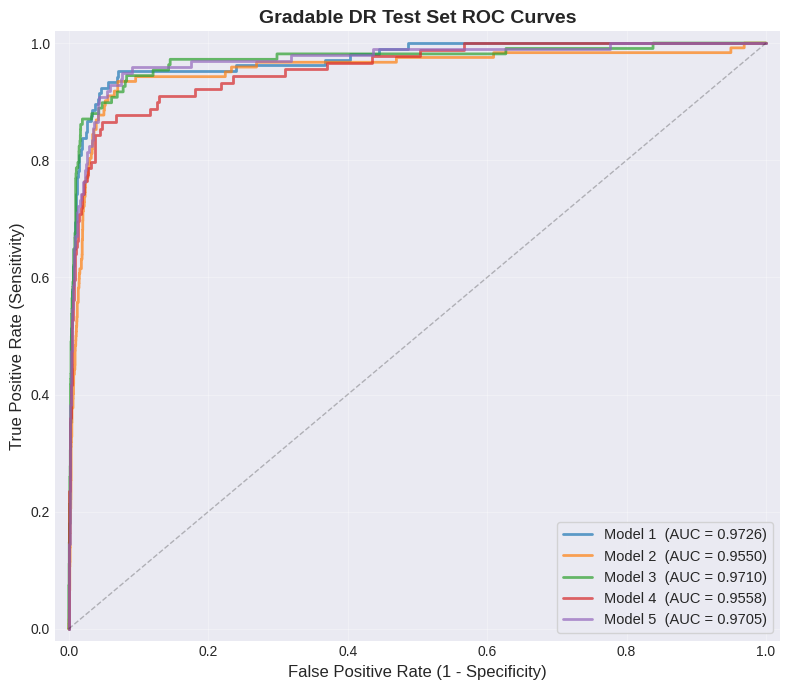

[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4215
single 4215
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4206
single 4206
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4143
single 4143
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4139
single 4139
[predictions_best_balanced_acc_model.csv] Labels changed: 0 / 4216
single 4216


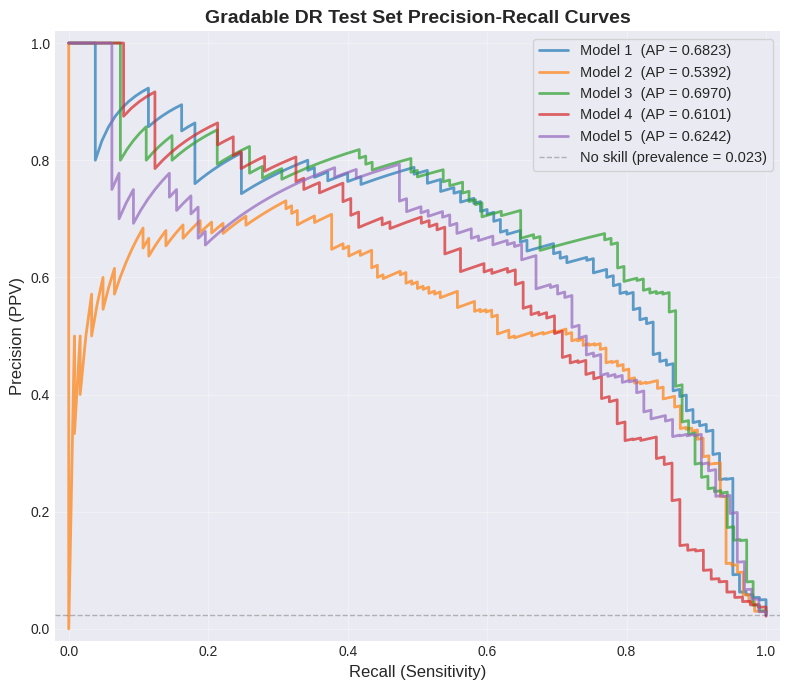

In [26]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# ===========================================================
# DIRECTORY
# ===========================================================
dr_test_dir = "/projects/retprogression/rgarridogarcia/gradable_dr_test"

# ===========================================================
# DISCOVER FOLD SUBFOLDERS
# ===========================================================
fold_dirs = sorted(glob.glob(os.path.join(dr_test_dir, "gradable_dr_test_cropped_centered_wt_allR_*")))
print(f"Found {len(fold_dirs)} fold directories:")
for d in fold_dirs:
    print(" ", os.path.basename(d))

# ===========================================================
# BUILD TABLE + COLLECT ROC DATA
# ===========================================================
rows = []
roc_data = []   # list of (fpr, tpr, auc, label)

MODEL_COLORS = plt.cm.tab10.colors[:5]

for i, fold_dir in enumerate(fold_dirs, start=1):
    pred_file = os.path.join(fold_dir, "predictions_best_balanced_acc_model.csv")
    if not os.path.exists(pred_file):
        print(f"Warning: predictions file not found in {os.path.basename(fold_dir)}")
        continue

    df_check = pd.read_csv(pred_file, nrows=1)
    type_model = 'ensemble' if ('y_true' in df_check.columns and 'y_prob_pos' in df_check.columns) else 'single'

    # --- Metrics ---
    metrics = compute_metrics(pred_file, threshold=0.5, type_model=type_model, corrections=corrections)
    metrics['Model'] = f'Model {i}'
    rows.append(metrics)

    # --- ROC ---
    y_true, y_prob = load_and_invert(pred_file, type_model=type_model, corrections=corrections)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    roc_data.append((fpr, tpr, auc, f'Model {i}', MODEL_COLORS[i - 1]))

# ===========================================================
# PERFORMANCE TABLE
# ===========================================================
dr_table = pd.DataFrame(rows)
dr_table = dr_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]
numeric_cols = ['Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC']
dr_table[numeric_cols] = dr_table[numeric_cols].round(4)

print("\n" + "="*80)
print("DR TEST SET PERFORMANCE METRICS")
print("="*80)
display(dr_table)

# Optional: save
# dr_table.to_csv(os.path.join(dr_test_dir, "dr_test_metrics.csv"), index=False)

# ===========================================================
# ROC CURVE
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(8, 7))

handles, labels = [], []

for fpr, tpr, auc, label, color in roc_data:
    ax.plot(fpr, tpr, color=color, linewidth=2, alpha=0.7)
    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"{label}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.25, linewidth=1)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("Gradable DR Test Set ROC Curves", fontsize=14, fontweight="bold")
ax.legend(handles, labels, loc="lower right", fontsize=10.5, frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(dr_test_dir, "dr_test_roc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

# ===========================================================
# PRECISION-RECALL CURVE
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(8, 7))

handles, labels = [], []

for fpr, tpr, auc, label, color in roc_data:
    # roc_data already has (fpr, tpr, auc, label, color) but we need
    # y_true/y_prob again for PRC — re-load from fold dirs
    pass

# Re-collect PRC data in the same loop style
for i, fold_dir in enumerate(fold_dirs, start=1):
    pred_file = os.path.join(fold_dir, "predictions_best_balanced_acc_model.csv")
    if not os.path.exists(pred_file):
        continue

    df_check = pd.read_csv(pred_file, nrows=1)
    type_model = 'ensemble' if ('y_true' in df_check.columns and 'y_prob_pos' in df_check.columns) else 'single'

    y_true, y_prob = load_and_invert(pred_file, type_model=type_model, corrections=corrections)

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    color = MODEL_COLORS[i - 1]

    ax.plot(recall, precision, color=color, linewidth=2, alpha=0.7)
    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"Model {i}  (AP = {ap:.4f})")

# No-skill baseline (prevalence line)
pos_prevalence = y_true.mean()
ax.axhline(y=pos_prevalence, color="k", linestyle="--", alpha=0.25, linewidth=1,
           label=f"No skill (prevalence = {pos_prevalence:.3f})")
no_skill_line = mlines.Line2D([], [], color="k", linestyle="--", alpha=0.25, linewidth=1)
handles.append(no_skill_line)
labels.append(f"No skill (prevalence = {pos_prevalence:.3f})")

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision (PPV)", fontsize=12)
ax.set_title("Gradable DR Test Set Precision-Recall Curves", fontsize=14, fontweight="bold")
ax.legend(handles, labels, loc="upper right", fontsize=10.5, frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(dr_test_dir, "dr_test_prc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## Val Performance Table and Curves

Found 10 fold directories:
  gradable_dr_val_Blackcropped_wt_allR_1
  gradable_dr_val_Blackcropped_wt_allR_2
  gradable_dr_val_Blackcropped_wt_allR_3
  gradable_dr_val_Blackcropped_wt_allR_4
  gradable_dr_val_Blackcropped_wt_allR_5
  gradable_dr_val_cropped_centered_wt_allR_1
  gradable_dr_val_cropped_centered_wt_allR_2
  gradable_dr_val_cropped_centered_wt_allR_3
  gradable_dr_val_cropped_centered_wt_allR_4
  gradable_dr_val_cropped_centered_wt_allR_5
single 4073
single 4073
single 4129
single 4129
single 4068
single 4068
single 4183
single 4183
single 4015
single 4015
single 4073
single 4073
single 4129
single 4129
single 4068
single 4068
single 4183
single 4183
single 4015
single 4015

DR VAL SET PERFORMANCE METRICS


,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,BlackCropped 1,0.8837,0.9631,0.9234,0.4919,0.9819,76,147,10,3840
1,BlackCropped 2,0.8037,0.9754,0.8896,0.5890,0.9768,86,99,21,3923
2,BlackCropped 3,0.7778,0.9672,0.8725,0.5217,0.9626,84,130,24,3830
3,BlackCropped 4,0.8319,0.9609,0.8964,0.5137,0.9773,94,159,19,3911
4,BlackCropped 5,0.9010,0.9699,0.9354,0.5871,0.9832,91,118,10,3796
5,CenteredCropped 1,0.9302,0.9719,0.9511,0.5755,0.9860,80,112,6,3875
6,CenteredCropped 2,0.7850,0.9804,0.8827,0.6222,0.9802,84,79,23,3943
7,CenteredCropped 3,0.9167,0.9735,0.9451,0.6346,0.9848,99,105,9,3855
8,CenteredCropped 4,0.8407,0.9717,0.9062,0.5882,0.9821,95,115,18,3955
9,CenteredCropped 5,0.8911,0.9755,0.9333,0.6272,0.9889,90,96,11,3818


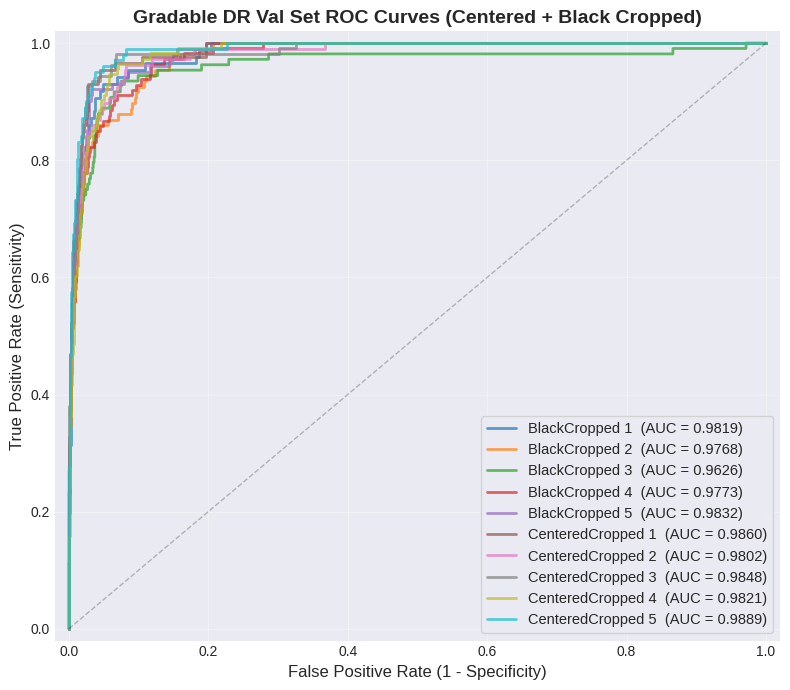

single 4073
single 4129
single 4068
single 4183
single 4015
single 4073
single 4129
single 4068
single 4183
single 4015


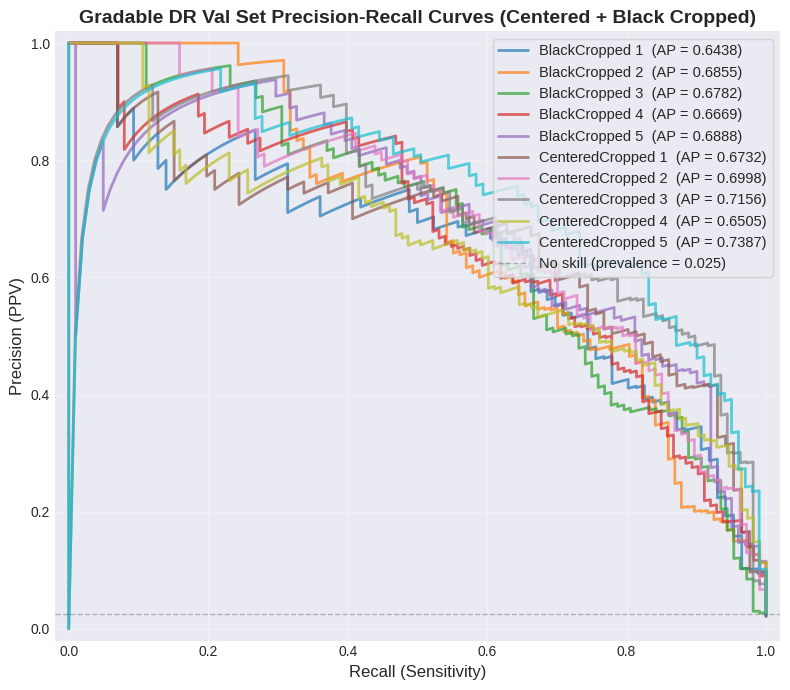

In [8]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# ===========================================================
# DIRECTORY
# ===========================================================
dr_test_dir = "/projects/retprogression/rgarridogarcia/gradable_dr_val"

# ===========================================================
# DISCOVER FOLD SUBFOLDERS
# ===========================================================
fold_dirs = sorted(
    glob.glob(os.path.join(dr_test_dir, "gradable_dr_val_cropped_centered_wt_allR_*"))
    + glob.glob(os.path.join(dr_test_dir, "gradable_dr_val_Blackcropped_wt_allR_*"))
)
print(f"Found {len(fold_dirs)} fold directories:")
for d in fold_dirs:
    print(" ", os.path.basename(d))


def get_model_label(fold_dir):
    """Derive a readable label from the folder name."""
    basename = os.path.basename(fold_dir)
    fold_num = basename.split("_")[-1]
    if "Blackcropped" in basename:
        return f"BlackCropped {fold_num}"
    elif "cropped_centered" in basename:
        return f"CenteredCropped {fold_num}"
    else:
        return basename


# ===========================================================
# BUILD TABLE + COLLECT ROC DATA
# ===========================================================
rows = []
roc_data = []   # list of (fpr, tpr, auc, label, color)

MODEL_COLORS = plt.cm.tab10.colors[:20]

for i, fold_dir in enumerate(fold_dirs, start=1):
    model_label = get_model_label(fold_dir)

    pred_file = os.path.join(fold_dir, "predictions_best_balanced_acc_model.csv")
    if not os.path.exists(pred_file):
        print(f"Warning: predictions file not found in {os.path.basename(fold_dir)}")
        continue

    df_check = pd.read_csv(pred_file, nrows=1)
    type_model = 'ensemble' if ('y_true' in df_check.columns and 'y_prob_pos' in df_check.columns) else 'single'

    # --- Metrics ---
    metrics = compute_metrics(pred_file, threshold=0.5, type_model=type_model, corrections=corrections)
    metrics['Model'] = model_label
    rows.append(metrics)

    # --- ROC ---
    y_true, y_prob = load_and_invert(pred_file, type_model=type_model, corrections=corrections)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    roc_data.append((fpr, tpr, auc, model_label, MODEL_COLORS[i - 1]))

# ===========================================================
# PERFORMANCE TABLE
# ===========================================================
dr_table = pd.DataFrame(rows)
dr_table = dr_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]
numeric_cols = ['Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC']
dr_table[numeric_cols] = dr_table[numeric_cols].round(4)

print("\n" + "="*80)
print("DR VAL SET PERFORMANCE METRICS")
print("="*80)
display(dr_table)

# Optional: save
# dr_table.to_csv(os.path.join(dr_test_dir, "dr_test_metrics.csv"), index=False)

# ===========================================================
# ROC CURVE
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(8, 7))

handles, labels = [], []

for fpr, tpr, auc, label, color in roc_data:
    ax.plot(fpr, tpr, color=color, linewidth=2, alpha=0.7)
    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"{label}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.25, linewidth=1)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("Gradable DR Val Set ROC Curves (Centered + Black Cropped)", fontsize=14, fontweight="bold")
ax.legend(handles, labels, loc="lower right", fontsize=10.5, frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(dr_test_dir, "dr_val_roc_curves_all.png"), dpi=300, bbox_inches="tight")
plt.show()

# ===========================================================
# PRECISION-RECALL CURVE
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(8, 7))

handles, labels = [], []

for i, fold_dir in enumerate(fold_dirs, start=1):
    model_label = get_model_label(fold_dir)

    pred_file = os.path.join(fold_dir, "predictions_best_balanced_acc_model.csv")
    if not os.path.exists(pred_file):
        continue

    df_check = pd.read_csv(pred_file, nrows=1)
    type_model = 'ensemble' if ('y_true' in df_check.columns and 'y_prob_pos' in df_check.columns) else 'single'

    y_true, y_prob = load_and_invert(pred_file, type_model=type_model, corrections=corrections)

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    color = MODEL_COLORS[i - 1]

    ax.plot(recall, precision, color=color, linewidth=2, alpha=0.7)
    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"{model_label}  (AP = {ap:.4f})")

# No-skill baseline (prevalence line)
pos_prevalence = y_true.mean()
ax.axhline(y=pos_prevalence, color="k", linestyle="--", alpha=0.25, linewidth=1)
no_skill_line = mlines.Line2D([], [], color="k", linestyle="--", alpha=0.25, linewidth=1)
handles.append(no_skill_line)
labels.append(f"No skill (prevalence = {pos_prevalence:.3f})")

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision (PPV)", fontsize=12)
ax.set_title("Gradable DR Val Set Precision-Recall Curves (Centered + Black Cropped)", fontsize=14, fontweight="bold")
ax.legend(handles, labels, loc="upper right", fontsize=10.5, frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(dr_test_dir, "dr_val_prc_curves_all.png"), dpi=300, bbox_inches="tight")
plt.show()

## Val and Test Curves together

single 4073
single 4129
single 4068
single 4183
single 4015
single 4215
single 4206
single 4143
single 4139
single 4216


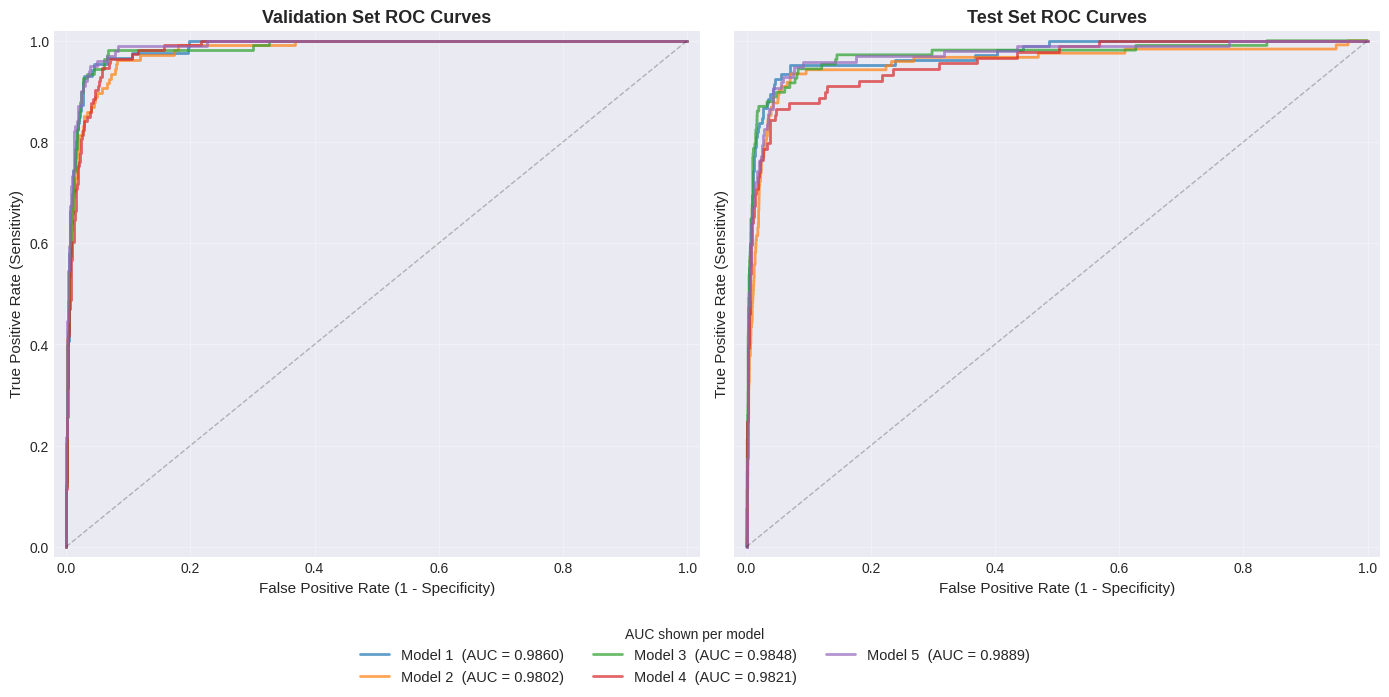

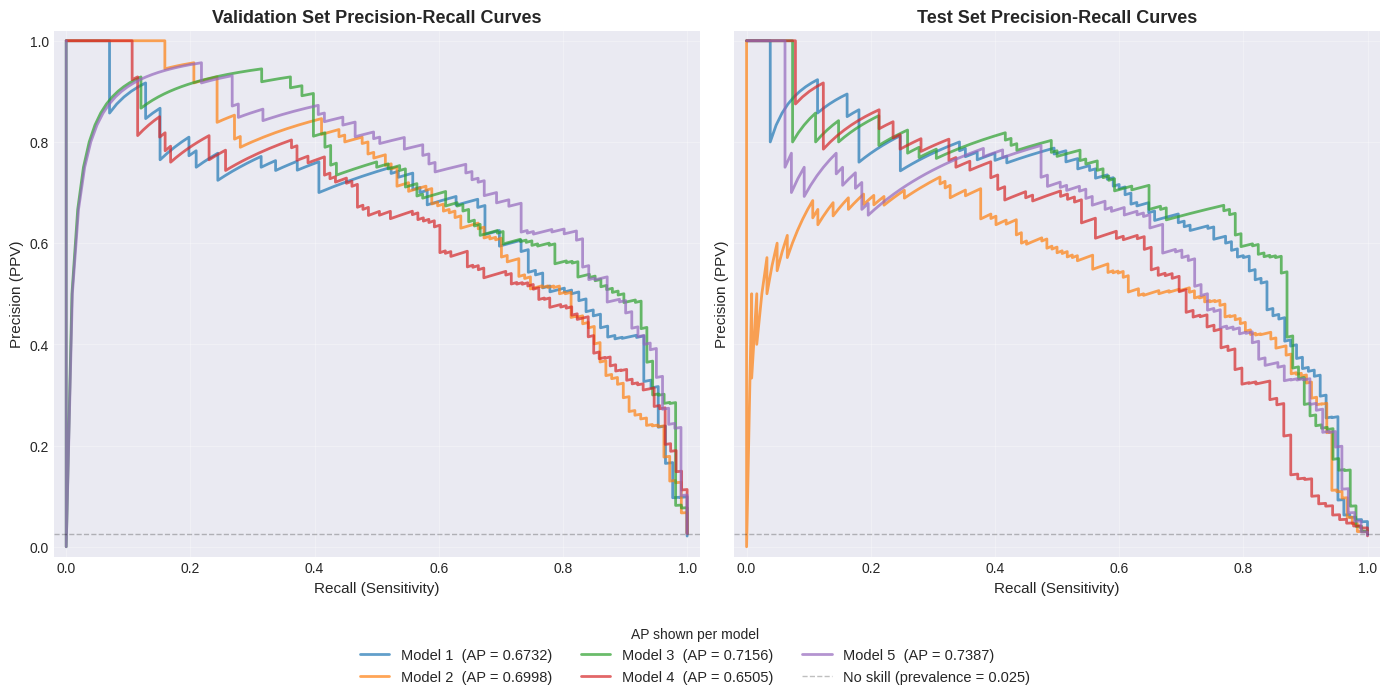

## Test1 and Test 2 Curves

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
[predictions_model_1_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_1_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_2_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_2_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_3_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_3_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_4_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_4_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_5_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_5_validation.csv] Labels changed: 9 / 826
single 826
[ensemble_average.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_average.csv] Labels changed: 9 / 826
ensemble 826


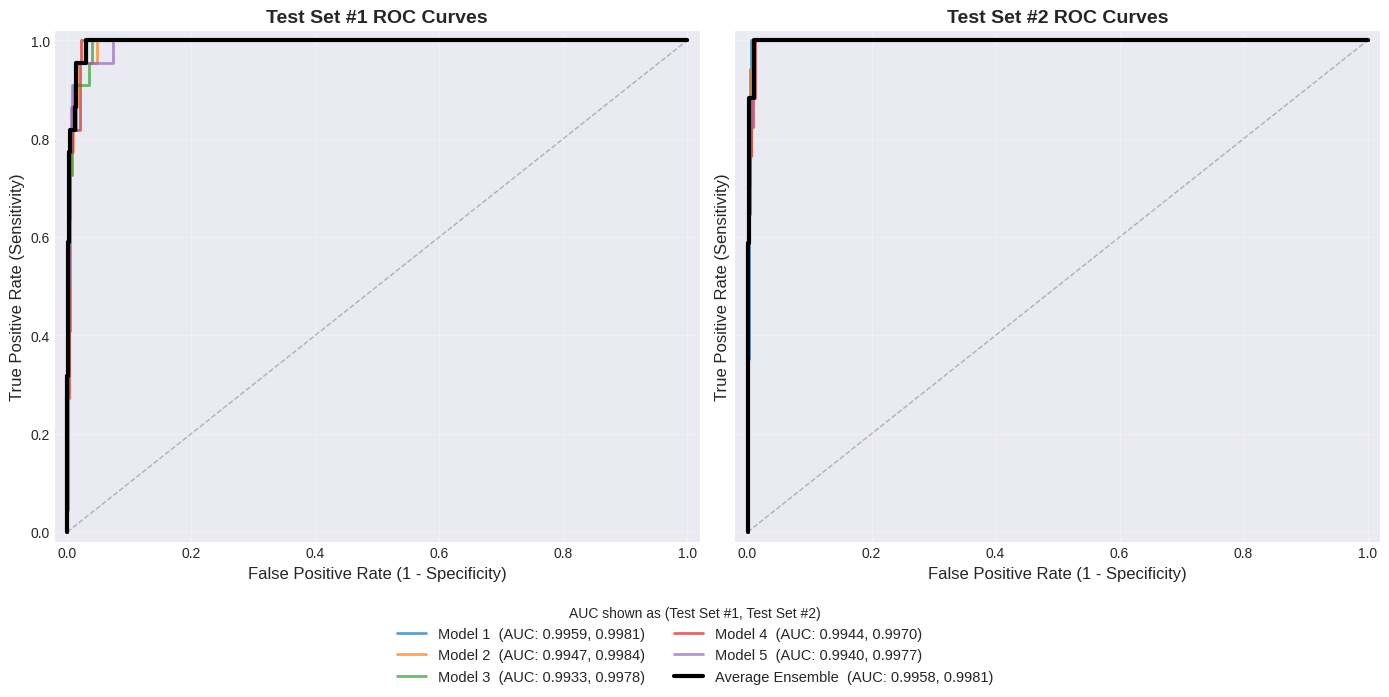

[predictions_model_1_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_1_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_2_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_2_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_3_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_3_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_4_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_4_validation.csv] Labels changed: 9 / 826
single 826
[predictions_model_5_calibration.csv] Labels changed: 11 / 825
single 825
[predictions_model_5_validation.csv] Labels changed: 9 / 826
single 826
[ensemble_average.csv] Labels changed: 11 / 825
ensemble 825
[ensemble_average.csv] Labels changed: 9 / 826
ensemble 826


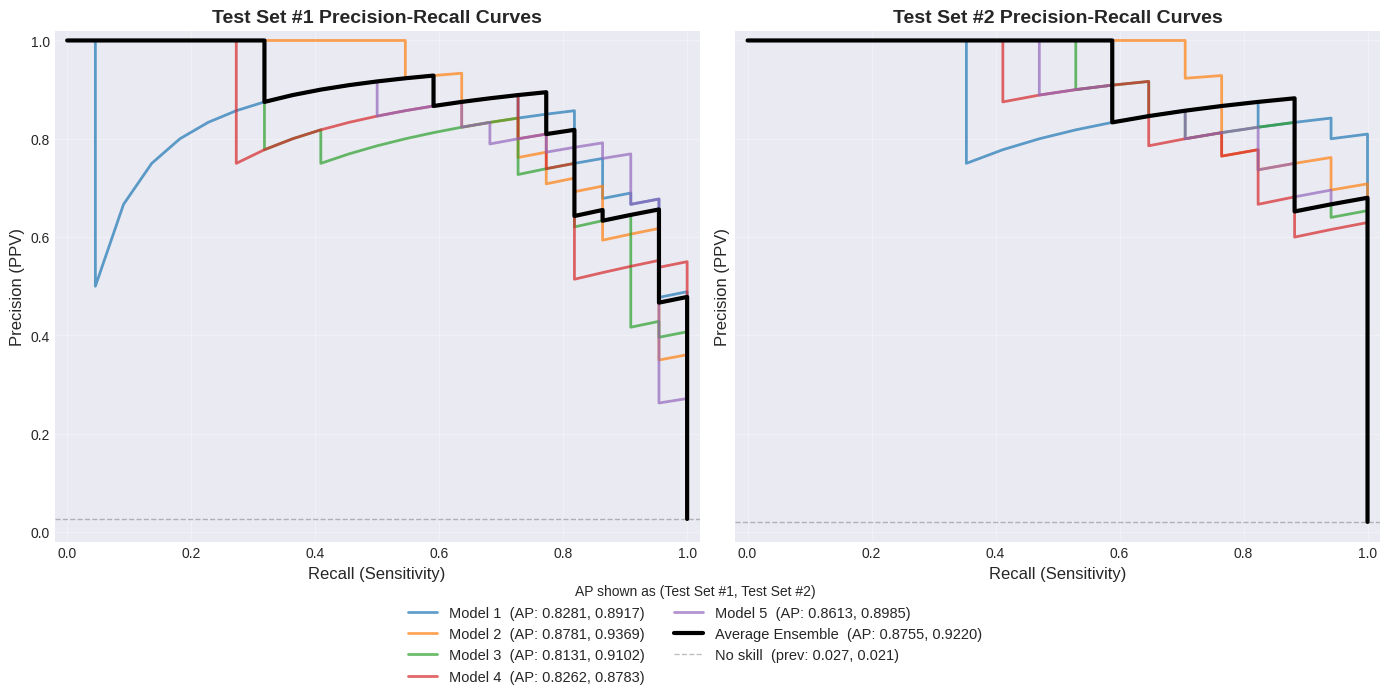

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.metrics import roc_curve, roc_auc_score
import glob
import os

# ===========================================================
# REUSE EXISTING FUNCTIONS FROM YOUR PIPELINE
# (load_corrections, load_predictions, load_and_invert)
# ===========================================================

def compute_roc(file_path, type_model='single', corrections=None):
    """Return fpr, tpr, AUC for a prediction file."""
    y_true, y_prob = load_and_invert(file_path, type_model=type_model, corrections=corrections)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    return fpr, tpr, auc


# ===========================================================
# FILE PATHS  (edit if needed)
# ===========================================================
corrections = load_corrections(
    "/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv"
)

individual_cal_files = sorted(glob.glob(
    "/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv"
))
individual_test_files = sorted(glob.glob(
    "/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv"
))

ensemble_cal_dir  = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split"
ensemble_test_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split"

def get_valid_ensemble_files(directory):
    files = glob.glob(os.path.join(directory, "ensemble_*.csv"))
    valid = []
    for f in files:
        df = pd.read_csv(f, nrows=1)
        if "y_true" in df.columns and "y_prob_pos" in df.columns:
            valid.append(f)
    return valid

ensemble_cal_files  = get_valid_ensemble_files(ensemble_cal_dir)
ensemble_test_files = get_valid_ensemble_files(ensemble_test_dir)

# Pick the Average ensemble file (adjust filename pattern if needed)
def get_ensemble_file(files, method="average"):
    matches = [f for f in files if method in os.path.basename(f).lower()]
    if not matches:
        raise FileNotFoundError(f"No ensemble file found for method='{method}'")
    return matches[0]

ensemble_cal_avg  = get_ensemble_file(ensemble_cal_files,  "average")
ensemble_test_avg = get_ensemble_file(ensemble_test_files, "average")


# ===========================================================
# COLORS
# ===========================================================
MODEL_COLORS = plt.cm.tab10.colors[:5]   # 5 distinct colors for models 1-5


# ===========================================================
# PLOT
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

handles, labels = [], []

for i in range(1, 6):
    cal_file  = [f for f in individual_cal_files  if f"predictions_model_{i}_" in f][0]
    test_file = [f for f in individual_test_files if f"predictions_model_{i}_" in f][0]

    fpr_c, tpr_c, auc_c = compute_roc(cal_file,  type_model='single', corrections=corrections)
    fpr_t, tpr_t, auc_t = compute_roc(test_file, type_model='single', corrections=corrections)

    color = MODEL_COLORS[i - 1]
    ax1.plot(fpr_c, tpr_c, color=color, alpha=0.7, linewidth=2)
    ax2.plot(fpr_t, tpr_t, color=color, alpha=0.7, linewidth=2)

    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"Model {i}  (AUC: {auc_c:.4f}, {auc_t:.4f})")

# Average ensemble
fpr_c_e, tpr_c_e, auc_c_e = compute_roc(ensemble_cal_avg,  type_model='ensemble', corrections=corrections)
fpr_t_e, tpr_t_e, auc_t_e = compute_roc(ensemble_test_avg, type_model='ensemble', corrections=corrections)

ax1.plot(fpr_c_e, tpr_c_e, color="black", linewidth=3)
ax2.plot(fpr_t_e, tpr_t_e, color="black", linewidth=3)

ens_line = mlines.Line2D([], [], color="black", linewidth=3)
handles.append(ens_line)
labels.append(f"Average Ensemble  (AUC: {auc_c_e:.4f}, {auc_t_e:.4f})")

# Random baseline
for ax in (ax1, ax2):
    ax.plot([0, 1], [0, 1], "k--", alpha=0.25, linewidth=1)
    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

ax1.set_title("Test Set #1 ROC Curves", fontsize=14, fontweight="bold")
ax2.set_title("Test Set #2 ROC Curves", fontsize=14, fontweight="bold")

# Legend: AUC pairs shown as (Test Set #1, Test Set #2)
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    fontsize=10.5,
    frameon=False,
    title="AUC shown as (Test Set #1, Test Set #2)",
    title_fontsize=10
)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.savefig("roc_curves_test_sets.png", dpi=300, bbox_inches="tight")
plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

def compute_prc(file_path, type_model='single', corrections=None):
    """Return precision, recall, AP for a prediction file."""
    y_true, y_prob = load_and_invert(file_path, type_model=type_model, corrections=corrections)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    prevalence = y_true.mean()
    return precision, recall, ap, prevalence


# ===========================================================
# PLOT
# ===========================================================
plt.style.use("seaborn-v0_8-darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

handles, labels = [], []

for i in range(1, 6):
    cal_file  = [f for f in individual_cal_files  if f"predictions_model_{i}_" in f][0]
    test_file = [f for f in individual_test_files if f"predictions_model_{i}_" in f][0]

    prec_c, rec_c, ap_c, prev_c = compute_prc(cal_file,  type_model='single', corrections=corrections)
    prec_t, rec_t, ap_t, prev_t = compute_prc(test_file, type_model='single', corrections=corrections)

    color = MODEL_COLORS[i - 1]
    ax1.plot(rec_c, prec_c, color=color, alpha=0.7, linewidth=2)
    ax2.plot(rec_t, prec_t, color=color, alpha=0.7, linewidth=2)

    line = mlines.Line2D([], [], color=color, linewidth=2, alpha=0.7)
    handles.append(line)
    labels.append(f"Model {i}  (AP: {ap_c:.4f}, {ap_t:.4f})")

# Average ensemble
prec_c_e, rec_c_e, ap_c_e, prev_c_e = compute_prc(ensemble_cal_avg,  type_model='ensemble', corrections=corrections)
prec_t_e, rec_t_e, ap_t_e, prev_t_e = compute_prc(ensemble_test_avg, type_model='ensemble', corrections=corrections)

ax1.plot(rec_c_e, prec_c_e, color="black", linewidth=3)
ax2.plot(rec_t_e, prec_t_e, color="black", linewidth=3)

ens_line = mlines.Line2D([], [], color="black", linewidth=3)
handles.append(ens_line)
labels.append(f"Average Ensemble  (AP: {ap_c_e:.4f}, {ap_t_e:.4f})")

# No-skill baselines (prevalence per set)
ax1.axhline(y=prev_c, color="k", linestyle="--", alpha=0.25, linewidth=1)
ax2.axhline(y=prev_t, color="k", linestyle="--", alpha=0.25, linewidth=1)

no_skill_line = mlines.Line2D([], [], color="k", linestyle="--", alpha=0.25, linewidth=1)
handles.append(no_skill_line)
labels.append(f"No skill  (prev: {prev_c:.3f}, {prev_t:.3f})")

for ax in (ax1, ax2):
    ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
    ax.set_ylabel("Precision (PPV)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

ax1.set_title("Test Set #1 Precision-Recall Curves", fontsize=14, fontweight="bold")
ax2.set_title("Test Set #2 Precision-Recall Curves", fontsize=14, fontweight="bold")

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    fontsize=10.5,
    frameon=False,
    title="AP shown as (Test Set #1, Test Set #2)",
    title_fontsize=10
)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.savefig("prc_curves_test_sets.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
import pandas as pd
import numpy as np
import glob
import os

# ===========================================================
# CONFIGURATION — change these two variables
# ===========================================================
individual_model = 1       # which model (1–5)
metric = 'TP'              # 'TP', 'FP', 'FN', or 'TN'
threshold = 0.5
n_samples = 10
random_seed = 42
# ===========================================================

METRIC_MAP = {
    'TP': (1, 1),
    'TN': (0, 0),
    'FP': (0, 1),
    'FN': (1, 0),
}
if metric not in METRIC_MAP:
    raise ValueError(f"metric must be one of {list(METRIC_MAP.keys())}")

true_target, pred_target = METRIC_MAP[metric]

# ── Load corrections ──────────────────────────────────────
corrections_path = "/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv"
df_corr = pd.read_csv(corrections_path)
df_corr['Id'] = df_corr['Id'].str.replace('.jpg', '', regex=False).str.strip()
corrections = dict(zip(df_corr['Id'].astype(int), df_corr['New label'].map({'G': 1, 'U': 0})))

# ── Find val fold directory for selected model ────────────
dr_val_dir = "/projects/retprogression/rgarridogarcia/gradable_dr_val"
val_fold_dirs = sorted(glob.glob(os.path.join(dr_val_dir, "gradable_dr_val_cropped_centered_wt_allR_*")))

if individual_model > len(val_fold_dirs):
    raise ValueError(f"Model {individual_model} not found — only {len(val_fold_dirs)} fold(s) available.")

fold_dir = val_fold_dirs[individual_model - 1]
print(f"Val fold dir: {fold_dir}")

# ── Find prediction file (supports both naming formats) ───
def find_pred_file(fold_dir):
    # Format 1: predictions_best_balanced_acc_model.csv
    f1 = os.path.join(fold_dir, "predictions_best_balanced_acc_model.csv")
    if os.path.exists(f1):
        return f1, "best_balanced_acc"
    # Format 2: predictions_model_*_validation.csv
    matches = glob.glob(os.path.join(fold_dir, "predictions_model_*_validation.csv"))
    if matches:
        return matches[0], "validation"
    # Format 3: predictions_model_*_calibration.csv
    matches = glob.glob(os.path.join(fold_dir, "predictions_model_*_calibration.csv"))
    if matches:
        return matches[0], "calibration"
    return None, None

pred_file, pred_format = find_pred_file(fold_dir)
if pred_file is None:
    raise FileNotFoundError(f"No prediction file found in {fold_dir}")
print(f"Prediction file : {pred_file} (format: {pred_format})")

# ── Load, correct, invert, predict ───────────────────────
def prepare(file_path, corrections, threshold):
    df = pd.read_csv(file_path)

    if 'true_label' in df.columns and 'prob_class_1' in df.columns:
        id_col, label_col, prob_col = 'image_id', 'true_label', 'prob_class_1'
    elif 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        id_col, label_col, prob_col = 'id', 'y_true', 'y_prob_pos'
    else:
        raise ValueError(f"Unknown columns in {file_path}: {df.columns.tolist()}")

    df = df[[id_col, label_col, prob_col]].copy()
    df.columns = ['image_id', 'true_label', 'prob']

    # Apply corrections
    df['image_id_int'] = pd.to_numeric(df['image_id'], errors='coerce')
    corrected = df['image_id_int'].map(corrections)
    mask = corrected.notna() & (corrected != df['true_label'])
    df.loc[mask, 'true_label'] = corrected[mask].astype(df['true_label'].dtype)
    print(f"  Labels corrected: {mask.sum()} / {len(df)}")

    # Invert
    df['true_label'] = 1 - df['true_label']
    df['prob']       = 1 - df['prob']

    df['predicted_label'] = (df['prob'] >= threshold).astype(int)
    return df

df_all = prepare(pred_file, corrections, threshold)

# ── Filter by metric and sample ───────────────────────────
mask = (df_all['true_label'] == true_target) & (df_all['predicted_label'] == pred_target)
df_filtered = df_all[mask].copy()

print(f"\n{'='*60}")
print(f"Model {individual_model} | Metric: {metric} | Total matches: {len(df_filtered)}")
print(f"  true_label={true_target}, predicted_label={pred_target}, threshold={threshold}")
print(f"{'='*60}")

if len(df_filtered) == 0:
    print("No samples found for this metric.")
else:
    sample = df_filtered.sample(n=min(n_samples, len(df_filtered)), random_state=random_seed)
    sample = sample[['image_id', 'true_label', 'predicted_label', 'prob']].reset_index(drop=True)
    sample.columns = ['Image ID', 'True Label', 'Predicted Label', 'Probability']
    display(sample)

    # ── Check if sampled IDs exist in the test CSV ────────
    test_csv_path = "/projects/retprogression/gradable_dr_new_5k_clean_test.csv"
    df_test = pd.read_csv(test_csv_path)
    id_col_name = 'ID' if 'ID' in df_test.columns else df_test.columns[0]
    df_test[id_col_name] = pd.to_numeric(df_test[id_col_name], errors='coerce')

    sampled_ids = sample['Image ID'].astype(int)
    in_test = sampled_ids.isin(df_test[id_col_name])
    sample['In Test CSV'] = in_test.values

    print(f"\n{'='*60}")
    print(f"IDs found in test CSV: {in_test.sum()} / {len(sampled_ids)}")
    print(f"{'='*60}")
    display(sample[['Image ID', 'True Label', 'Predicted Label', 'Probability', 'In Test CSV']])
    # ── Print sampled IDs separated by spaces ─────────────────
    print("\nSampled IDs:")
    print(" ".join(sample['Image ID'].astype(str).tolist()))

# ── Class distribution after inversion ───────────────────
print(f"\n{'='*60}")
print(f"Class distribution after inversion (full dataset):")
counts = df_all['true_label'].value_counts().sort_index()
for label, count in counts.items():
    label_name = "Gradable" if label == 1 else "Ungradable"
    pct = 100 * count / len(df_all)
    print(f"  Class {label} ({label_name}): {count} samples ({pct:.1f}%)")
print(f"{'='*60}")


Val fold dir: /projects/retprogression/rgarridogarcia/gradable_dr_val/gradable_dr_val_cropped_centered_wt_allR_1
Prediction file : /projects/retprogression/rgarridogarcia/gradable_dr_val/gradable_dr_val_cropped_centered_wt_allR_1/predictions_best_balanced_acc_model.csv (format: best_balanced_acc)
  Labels corrected: 0 / 4073

Model 1 | Metric: TP | Total matches: 80
  true_label=1, predicted_label=1, threshold=0.5


,Image ID,True Label,Predicted Label,Probability
0,401681,1,1,0.837368
1,50791,1,1,0.990375
2,381203,1,1,0.984186
3,401683,1,1,0.762377
4,376607,1,1,0.962678
5,401078,1,1,0.950301
6,334815,1,1,0.947672
7,581375,1,1,0.972284
8,265413,1,1,0.966633
9,334817,1,1,0.952262



IDs found in test CSV: 0 / 10


,Image ID,True Label,Predicted Label,Probability,In Test CSV
0,401681,1,1,0.837368,False
1,50791,1,1,0.990375,False
2,381203,1,1,0.984186,False
3,401683,1,1,0.762377,False
4,376607,1,1,0.962678,False
5,401078,1,1,0.950301,False
6,334815,1,1,0.947672,False
7,581375,1,1,0.972284,False
8,265413,1,1,0.966633,False
9,334817,1,1,0.952262,False



Sampled IDs:
401681 50791 381203 401683 376607 401078 334815 581375 265413 334817

Class distribution after inversion (full dataset):
  Class 0 (Ungradable): 3987 samples (97.9%)
  Class 1 (Gradable): 86 samples (2.1%)


## Uncorrected Performance Test1 and Test2

In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score
import glob
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def load_corrections(corrections_path):
    """Load correction CSV and return a dict mapping id -> new numeric label (G=1, U=0)."""
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    return dict(zip(df['Id'], df['New label'].map(label_map)))

def load_predictions(file_path, type_model='single', corrections=None):
    df = pd.read_csv(file_path)
    
    # Handle ensemble files (y_true, y_prob_pos)
    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values
        y_prob = df['y_prob_pos'].values
        id_col = 'id'
    
    # Handle individual model files (true_label, prob_class_1)
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values
        y_prob = df['prob_class_1'].values
        id_col = 'image_id'
    
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")
    
    # Apply corrections if provided
    if corrections and id_col in df.columns:
        for idx, row in df.iterrows():
            img_id = row[id_col]
            if img_id in corrections:
                y_true[idx] = corrections[img_id]
    
    return y_true, y_prob


def load_and_invert(file_path, type_model='single', corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true    # invert class labels
    y_prob = 1 - y_prob    # invert probabilities
    print(type_model, len(y_true))
    return y_true, y_prob



def compute_metrics(file_path, threshold=0.5, type_model='single', corrections=None):
    y_true, y_prob = load_and_invert(file_path, type_model=type_model, corrections=corrections)
    
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (sensitivity + specificity) / 2
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    
    return {
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Balanced_Accuracy': balanced_accuracy,
        'F1': f1,
        'AUC': auc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    }

# ===========================================================
# 0. LOAD LABEL CORRECTIONS
# ===========================================================
corrections = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

# ===========================================================
# 1. GET ALL INDIVIDUAL CALIBRATION MODEL FILES
# ===========================================================
individual_cal_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv")
)

print("Found individual calibration models:", len(individual_cal_files))


# ===========================================================
# 2. GET ALL INDIVIDUAL VALIDATION MODEL FILES
# ===========================================================
individual_val_files = sorted(
    glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_validation.csv")
)

print("Found individual validation models:", len(individual_val_files))


# ===========================================================
# 3. GET CALIBRATION ENSEMBLE FILES
# ===========================================================
ensemble_cal_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split"

all_ensemble_cal_files = glob.glob(os.path.join(ensemble_cal_dir, "ensemble_*.csv"))

ensemble_cal_files = []
for f in all_ensemble_cal_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_cal_files.append(f)

print("Valid ensemble calibration files:", len(ensemble_cal_files))


# ===========================================================
# 4. GET VALIDATION ENSEMBLE FILES
# ===========================================================
ensemble_val_dir = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split"

all_ensemble_val_files = glob.glob(os.path.join(ensemble_val_dir, "ensemble_*.csv"))

ensemble_val_files = []
for f in all_ensemble_val_files:
    df = pd.read_csv(f, nrows=1)
    if ("y_true" in df.columns) and ("y_prob_pos" in df.columns):
        ensemble_val_files.append(f)

print("Valid ensemble validation files:", len(ensemble_val_files))


# ===========================================================
# CREATE CALIBRATION TABLE
# ===========================================================
cal_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_cal_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single')
    metrics['Model'] = f'Model {i}'
    cal_rows.append(metrics)

# All ensemble methods
for f in ensemble_cal_files:
    method_name = os.path.basename(f).replace('ensemble_', '').replace('.csv', '')
    metrics = compute_metrics(f, threshold=0.5, type_model='ensemble')
    metrics['Model'] = method_name.replace('_', ' ').title()
    cal_rows.append(metrics)

# Create DataFrame
cal_table = pd.DataFrame(cal_rows)
cal_table = cal_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]

# Round numeric columns to 4 decimal places
numeric_cols = ['Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC']
cal_table[numeric_cols] = cal_table[numeric_cols].round(4)


# ===========================================================
# CREATE VALIDATION/TEST TABLE
# ===========================================================
test_rows = []

# Individual models 1-5
for i in range(1, 6):
    file = [f for f in individual_val_files if f"predictions_model_{i}_" in f][0]
    metrics = compute_metrics(file, threshold=0.5, type_model='single')
    metrics['Model'] = f'Model {i}'
    test_rows.append(metrics)

# All ensemble methods
for f in ensemble_val_files:
    method_name = os.path.basename(f).replace('ensemble_', '').replace('.csv', '')
    metrics = compute_metrics(f, threshold=0.5, type_model='ensemble')
    metrics['Model'] = method_name.replace('_', ' ').title()
    test_rows.append(metrics)

# Create DataFrame
test_table = pd.DataFrame(test_rows)
test_table = test_table[['Model', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN']]

# Round numeric columns to 4 decimal places
test_table[numeric_cols] = test_table[numeric_cols].round(4)


# ===========================================================
# DISPLAY TABLES
# ===========================================================
print("="*80)
print("CALIBRATION PERIOD METRICS")
print("="*80)
display(cal_table)

print("\n" + "="*80)
print("VALIDATION/TEST PERIOD METRICS")
print("="*80)
display(test_table)


# ===========================================================
# OPTIONAL: SAVE TO CSV
# ===========================================================
'''cal_table.to_csv('calibration_metrics.csv', index=False)
test_table.to_csv('validation_metrics.csv', index=False)'''

Found individual calibration models: 5
Found individual validation models: 5
Valid ensemble calibration files: 8
Valid ensemble validation files: 8
single 825
single 825
single 825
single 825
single 825
ensemble 825
ensemble 825
ensemble 825
ensemble 825
ensemble 825
ensemble 825
ensemble 825
ensemble 825
single 826
single 826
single 826
single 826
single 826
ensemble 826
ensemble 826
ensemble 826
ensemble 826
ensemble 826
ensemble 826
ensemble 826
ensemble 826
CALIBRATION PERIOD METRICS


,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,Model 1,0.5789,0.9876,0.7833,0.5500,0.8965,11,10,8,796
1,Model 2,0.7368,0.9640,0.8504,0.4516,0.9197,14,29,5,777
2,Model 3,0.6842,0.9715,0.8278,0.4727,0.9323,13,23,6,783
3,Model 4,0.5789,0.9727,0.7758,0.4231,0.9100,11,22,8,784
4,Model 5,0.7368,0.9764,0.8566,0.5385,0.9308,14,19,5,787
5,Average,0.7368,0.9777,0.8573,0.5490,0.9282,14,18,5,788
6,Confidence,0.7368,0.9764,0.8566,0.5385,0.9280,14,19,5,787
7,Logit,0.7368,0.9777,0.8573,0.5490,0.9248,14,18,5,788
8,Majority 60,0.7368,0.9777,0.8573,0.5490,0.9282,14,18,5,788
9,Majority 80,0.7368,0.9777,0.8573,0.5490,0.9282,14,18,5,788



VALIDATION/TEST PERIOD METRICS


,Model,Sensitivity,Specificity,Balanced_Accuracy,F1,AUC,TP,FP,FN,TN
0,Model 1,0.6,0.9926,0.7963,0.6316,0.8535,12,6,8,800
1,Model 2,0.7,0.9752,0.8376,0.5185,0.8557,14,20,6,786
2,Model 3,0.7,0.9789,0.8395,0.5490,0.8674,14,17,6,789
3,Model 4,0.7,0.9801,0.8401,0.5600,0.8769,14,16,6,790
4,Model 5,0.7,0.9826,0.8413,0.5833,0.8596,14,14,6,792
5,Average,0.7,0.9851,0.8426,0.6087,0.8695,14,12,6,794
6,Confidence,0.7,0.9851,0.8426,0.6087,0.8695,14,12,6,794
7,Logit,0.7,0.9851,0.8426,0.6087,0.8717,14,12,6,794
8,Majority 60,0.7,0.9851,0.8426,0.6087,0.8695,14,12,6,794
9,Majority 80,0.7,0.9851,0.8426,0.6087,0.8695,14,12,6,794


"cal_table.to_csv('calibration_metrics.csv', index=False)\ntest_table.to_csv('validation_metrics.csv', index=False)"

In [24]:
unique_Ids = [605221, 605222, 605367, 605368, 605394, 605395, 605396, 605397, 605539, 605543, 605578, 605579, 605630, 605631, 605639, 605640, 605683, 605684, 605685, 605686, 605687, 605688, 605755, 605756, 605932, 605933, 605934, 605935, 605936, 605937, 605963, 605967, 605982, 605983, 605984, 605985, 605997, 606000, 606291, 606292, 606304, 606305, 606306, 606307, 606370, 606371, 606381, 606385, 606443, 606444, 606471, 606472, 606501, 606504, 606509, 606510, 606521, 606522, 606736, 606739, 606818, 606819, 606822, 607863, 607864, 607967, 607968, 608042, 608043, 608103, 608104, 608148, 608150, 608153, 608154, 608155, 608156, 608172, 608173, 608179, 608180, 608333, 608334, 608338, 608339, 608343, 608344, 608345, 608346, 608376, 608377, 608380, 608381, 608486, 608487, 608488, 608489, 608498, 608499, 608546, 608547, 608590, 608595, 608672, 608673, 608680, 608681, 608701, 608702, 608703, 608704, 608716, 608717, 608729, 608730, 608926, 608927, 608970, 608971, 609021, 609022, 609090, 609096, 609354, 609355, 609356, 609357, 609681, 609685, 609714, 609718, 609749, 609753, 609777, 609778, 609856, 609857, 609861, 609862, 609895, 609896, 609919, 609920, 609921, 609922, 609951, 609952, 609953, 609954, 609961, 609962, 609968, 609969, 609970, 609971, 609980, 609981, 610004, 610005, 610202, 610203, 610204, 610205, 610213, 610214, 610276, 610277, 610296, 610297, 610298, 610379, 610380, 610381, 610382, 610474, 610475, 610495, 610496, 610519, 610520, 610629, 610630, 610696, 610700, 610731, 610732, 610739, 610745, 610746, 610747, 610776, 610777, 610821, 610822, 610989, 610990, 610991, 610992, 611001, 611002, 611003, 611004, 611096, 611099, 611157, 611158, 611159, 611160, 611161, 611162, 611163, 611164, 611189, 611190, 611219, 611220, 611345, 611346, 611384, 611387, 611404, 611405, 611504, 611505, 611506, 611507, 611585, 611586, 611598, 611599, 611600, 611601, 611682, 611685, 611724, 611725, 611762, 611763, 611996, 611997, 611998, 611999, 612003, 612004, 612020, 612021, 612022, 612023, 612062, 612063, 612112, 612113, 612140, 612141, 612142, 612143, 612244, 612245, 612246, 612247, 612270, 612271, 612272, 612273, 612274, 612277, 612293, 612294, 612321, 612322, 612372, 612373, 612392, 612393, 612401, 612402, 612403, 612404, 612405, 612406, 612407, 612408, 612409, 612410, 612532, 612533, 612584, 612585, 612651, 612652, 612654, 612656, 612738, 612739, 612740, 612741, 612752, 612753, 612758, 612759, 612812, 612813, 612826, 612827, 612837, 612838, 612870, 612871, 612872, 612873, 612927, 612928, 612993, 612994, 613018, 613019, 613020, 613021, 613023, 613024, 613055, 613059, 613122, 613123, 613130, 613131, 613149, 613150, 613194, 613195, 613196, 613197, 613216, 613218, 613247, 613248, 613273, 613274, 613275, 613276, 613277, 613296, 613300, 613327, 613328, 613329, 613330, 613343, 613344, 613345, 613346, 613347, 613348, 613349, 613350, 613358, 613359, 613363, 613364, 613371, 613372, 613435, 613436, 613459, 613460, 613714, 613715, 613783, 613785, 613909, 613910, 613912, 613913, 613914, 613915, 613971, 613972, 614118, 614119, 615838, 615839, 615926, 615927, 615995, 615996, 616103, 616104, 616136, 616140, 616141, 616142, 616164, 616165, 616877, 616883, 616909, 616910, 616971, 616972, 617003, 617005, 617113, 617114, 617115, 617116, 617117, 617118, 617148, 617149, 617160, 617161, 617164, 617165, 617169, 617171, 617182, 617183, 617273, 617274, 617460, 617461, 617557, 617558, 617620, 617621, 617622, 617623, 617817, 617818, 617819, 617820, 617846, 617847, 617899, 617900, 618010, 618011, 618016, 618017, 618180, 618181, 618182, 618183, 618184, 618185, 618209, 618210, 618214, 618215, 618241, 618242, 618243, 618244, 618269, 618270, 618303, 618304, 618594, 618595, 618650, 618651, 618652, 618653, 618654, 618655, 618656, 618657, 618658, 618659, 618663, 618668, 618758, 618759, 618760, 618761, 618789, 618790, 618791, 618796, 618800, 618801, 618866, 618867, 618868, 618869, 618906, 618910, 618978, 618983, 619044, 619045, 619100, 619101, 619106, 619107, 619175, 619179, 619233, 619234, 619235, 619236, 619243, 619246, 619380, 619381, 619907, 619908, 619943, 619946, 619947, 619948, 619949, 619950, 620005, 620006, 620059, 620060, 620075, 620076, 620077, 620078, 620098, 620099, 620125, 620126, 620129, 620130, 620138, 620139, 620140, 620141, 620186, 620187, 620502, 620503, 620504, 620505, 620609, 620610, 620612, 620652, 620653, 620676, 620678, 620687, 620688, 620716, 620717, 620718, 620719, 620748, 620749, 620761, 620762, 620812, 620813, 620814, 620815, 620977, 620978, 621005, 621011, 621020, 621021, 621069, 621070, 621299, 621301, 621302, 621303, 621304, 621305, 621306, 621307, 621313, 621314, 621330, 621331, 621348, 621349, 621586, 621587, 621641, 621642, 621751, 621752, 621753, 621754, 621761, 621765, 621777, 621778, 621846, 621847, 621867, 621871, 621900, 621901, 621902, 621903, 622010, 622011, 622030, 622031, 622087, 622088, 622089, 622090, 622109, 622110, 622198, 622199, 622250, 622251, 622252, 622253, 622336, 622337, 622338, 622339, 622349, 622350, 622405, 622407, 622411, 622414, 622478, 622479, 622488, 622489, 622490, 622491, 622521, 622522, 622544, 622545, 622546, 622547, 622573, 622574, 622575, 622576, 622742, 622743, 622759, 622760, 622774, 622775, 622776, 622777, 622785, 622786, 622787, 622791, 622842, 622843, 622848, 622849, 622853, 622854, 622855, 622856, 622857, 622858, 622859, 622860, 622889, 622890, 622896, 622897, 622926, 622927, 622929, 622930, 622935, 622936, 622937, 622938, 622940, 622943, 623115, 623116, 623117, 623118, 623215, 623216, 623352, 623353, 623401, 623402, 623565, 623566, 623567, 623568, 623573, 623574, 623586, 623587, 623588, 623589, 623661, 623662, 623663, 623664, 623793, 623794, 623795, 623908, 623909, 623910, 623911, 623982, 623983, 623984, 623985, 624064, 624065, 624104, 624105, 624121, 624373, 624374, 624656, 624657, 624759, 624760, 624823, 624824, 624917, 624918, 624919, 624920, 624979, 624981, 624987, 624988, 624991, 624992, 624993, 624994, 624999, 625000, 625049, 625050, 625051, 625052, 625101, 625102, 625103, 625104, 625105, 625106, 625154, 625155, 625251, 625252, 625253, 625254, 625283, 625284, 625381, 625382, 625468, 625469, 625611, 625612, 626086, 626087, 626088, 626089, 626136, 626137, 626138, 626139, 626180, 626181, 626257, 626258, 626259, 626260, 626293, 626294, 626295, 626296, 626297, 626298, 626299, 626300, 626305, 626306, 626310, 626311, 626312, 626316, 626387, 626388, 626389, 626390, 626426, 626427, 626481, 626482, 626483, 626484, 626497, 626498, 626499, 626500, 626508, 626509, 626518, 626522, 626596, 626597, 626603, 626604, 626605, 626606, 626636, 626637, 626659, 626660, 626661, 626662, 626729, 626730, 626781, 626787, 626879, 626880, 627008, 627169, 627173, 627174, 627920, 627921, 627922, 627923, 628002, 628003, 628102, 628104, 628119, 628120, 628121, 628122, 628218, 628219, 628220, 628221, 628264, 628265, 628266, 628267, 628268, 628269, 628270, 628271, 628314, 628315, 628316, 628317, 628330, 628331, 628332, 628333, 628456, 628457, 628458, 628459, 628571, 628572, 628584, 628585, 629090, 629091, 629092, 629093, 629132, 629133, 629164, 629165, 629215, 629216, 629264, 629265, 629310, 629311, 629364, 629365, 629418, 629419, 629420, 629421, 629430, 629431, 629432, 629433, 629434, 629435, 629436, 629437, 629557, 629558, 629559, 629560, 629652, 629653, 629654, 629655, 629703, 629704, 629730, 629733, 629777, 629778, 629779, 629780, 629789, 629790, 629803, 629804, 629805, 629806, 629821, 629822, 629877, 629878, 629911, 629914, 629928, 629929, 629930, 629931, 629994, 629995, 629996, 630244, 630248, 630268, 630269, 630270, 630271, 630272, 630273, 630286, 630287, 630291, 630292, 630354, 630356, 630369, 630370, 630386, 630387, 630388, 630389, 630398, 630400, 630435, 630438, 630583, 630584, 630585, 630586, 630587, 630588, 630600, 630601, 630602, 630603, 630668, 630669, 630670, 630671, 630676, 630677, 630782, 630783, 630784, 630785, 630883, 630884, 630961, 630962, 631036, 631037, 631038, 631039, 631042, 631044, 631149, 631150, 631196, 631197, 631204, 631205, 631364, 631366, 631378, 631379, 631528, 631529, 631545, 631546, 631552, 631553, 631654, 631658, 631862, 631867, 631868, 631869, 631935, 631936, 631937, 631938, 632008, 632023, 632024, 632063, 632064, 632065, 632066, 632169, 632170, 632232, 632233, 632267, 632270, 632280, 632281, 632282, 632283, 632363, 632364, 632365, 632366, 632507, 632508, 632509, 632510, 632525, 632526, 632556, 632557, 632578, 632579, 632704, 632706, 632710, 632711, 632784, 632785, 632786, 632787, 632849, 632850, 632857, 632858, 632859, 632860, 632958, 632961, 633146, 633147, 633299, 633300, 633960, 633961, 633962, 633963, 634785, 634786, 634787, 634788, 634789, 634790, 634802, 634803, 634824, 634825, 634826, 634827, 634828, 634829, 634830, 634910, 634911, 635125, 635126, 635141, 635142, 635193, 635194, 635195, 635196, 635197, 635198, 635199, 635200, 635204, 635205, 635208, 635209, 635644, 635645, 635649, 635650, 635730, 635731, 635793, 635797, 635816, 635818, 635897, 635898, 635899, 635900, 635946, 635947, 635948, 635949, 635966, 635967, 636408, 636409, 636410, 636411, 636478, 636479, 636494, 636495, 636497, 636498, 636499, 636524, 636525, 636543, 636544, 636545, 636546, 636547, 636548, 636570, 636571, 636572, 636573, 636593, 636594, 636595, 636596, 636607, 636611, 636612, 636613, 636737, 636738, 636792, 636793, 636794, 636795, 636796, 636797, 636836, 636837, 636924, 636925, 636946, 636947, 637019, 637023, 637055, 637056, 637088, 637089, 637090, 637091, 637109, 637110, 637112, 637113, 637114, 637115, 637118, 637119, 637161, 637162, 637163, 637164, 637173, 637174, 637186, 637187, 637192, 637193, 637377, 637378, 637382, 637383, 637387, 637388, 637389, 637390, 637425, 637426, 637446, 637451, 637464, 637465, 637469, 637470, 637471, 637472, 637746, 637816, 637817, 637844, 637845, 637857, 637858, 637859, 637860, 637901, 637902, 637903, 637904, 637905, 637956, 637957, 637974, 637975, 638154, 638155, 638156, 638157, 638312, 638313, 638314, 638315, 638343, 638395, 638396, 638397, 638398, 638412, 638413, 638426, 638427, 638428, 638429, 638442, 638443, 638444, 638445, 638454, 638455, 638456, 638457, 638490, 638491, 638492, 638493, 638502, 638503, 638504, 638505, 638708, 638709, 638776, 638777, 638856, 638857, 638858, 638859, 639136, 639137, 639192, 639193, 639194, 639195, 639203, 639204, 639205, 639259, 639260, 640052, 640053, 640054, 640055, 640060, 640061, 640112, 640116, 640238, 640239, 640277, 640278, 640279, 640280, 640281, 640282, 640283, 640284, 640307, 640309, 640585, 640590, 641005, 641006, 641007, 641008, 641031, 641035, 641110, 641114, 641143, 641144, 641159, 641160, 641219, 641220, 641303, 641304, 641513, 641517, 641518, 641519, 641520, 641521, 641538, 641539, 641684, 641685, 641723, 641724, 641725, 641726, 641894, 641895, 641896, 641897, 642003, 642007, 642751, 642752, 642799, 642800, 642942, 642943, 643030, 643031, 643099, 643104, 643513, 643514, 643543, 643544, 643545, 643702, 643703, 643704, 643705, 643722, 643723, 643727, 643728, 643729, 643730, 643858, 643859, 643860, 643861, 643940, 643941, 643942, 643943, 644411, 644412, 644481, 644482, 644549, 644550, 644551, 644552, 644557, 644630, 644631, 644699, 644700, 644715, 644718, 644823, 644824, 644825, 644826, 644837, 644838, 644898, 644899, 644900, 644901, 644902, 644903, 644952, 644953, 644992, 644993, 644994, 644995, 645040, 645041, 645052, 645053, 645062, 645064, 645189, 645197, 645202, 645311, 645313, 645323, 645324, 645325, 645326, 645447, 645448, 645449, 645450, 645812, 645813, 645833, 645834, 645845, 645846, 645847, 645848, 645857, 645858, 645859, 645860, 645918, 645919, 645948, 645949, 645950, 645951, 645952, 645953, 645954, 645955, 645972, 645973, 645987, 645988, 645989, 645990, 646113, 646114, 646115, 646116, 646345, 646346, 646347, 646348, 646349, 646350, 646358, 646359, 646434, 646435, 646436, 646437, 646446, 646447, 646448, 646449, 646497, 646498, 646605, 646609, 646791, 646792, 647188, 647191, 647370, 647371, 647484, 647485, 647800, 647806, 647807, 647808, 647814, 647815, 647818, 647819, 647915, 647916, 647917, 647918, 647932, 647933, 648147, 648148, 648149, 648150, 648321, 648324, 648343, 648344, 648511, 648512, 648730, 648731, 648732, 648733, 648734, 648735, 648736, 648737, 648842, 648844, 648849, 648850, 648851, 648852, 648997, 648998, 649032, 649033, 649034, 649035, 649112, 649113, 649158, 649159, 649160, 649161, 650047, 650048, 650217, 650218, 650247, 650248, 650403, 650404, 650481, 650482, 650483, 650484, 650517, 650518, 650815, 650816, 650926, 650927, 651177, 651178, 651179, 651180, 651331, 651332, 651345, 651346, 651786, 651787, 651820, 651821, 651890, 651891, 651893, 651894, 651908, 651909, 651910, 651911, 651948, 651949, 651950, 651951, 652174, 652175, 652176, 652177, 652220, 652221, 652222, 652223, 652291, 652295, 652334, 652335, 652336, 652337, 652341, 652342, 652352, 652353, 652361, 652364, 652452, 652453, 652539, 652540, 652541, 652542, 652624, 652629, 652632, 652633, 652655, 652656, 653029, 653030, 653074, 653075, 653124, 653125, 653176, 653177, 653261, 653262, 653306, 653307, 653351, 653352, 653353, 653354, 653358, 653359, 653503, 653504, 653815, 653816, 653817, 653818, 654041, 654042, 654150, 654151, 654152, 654153, 654941, 654942, 655117, 655118, 655135, 655140, 655434, 655435]

In [25]:
# Pick one file (e.g., first calibration file)
sample_file = individual_cal_files[0]
print(f"Reading file: {os.path.basename(sample_file)}")

# Load the file
df = pd.read_csv(sample_file)
print(df['image_id'].unique())

# Check what ID columns exist
print(f"\nColumns in file: {df.columns.tolist()}")

# If there's an ID column, print unique IDs
if 'ID' in df.columns:
    unique_ids = df['ID'].unique()
    print(f"\nNumber of unique IDs: {len(unique_ids)}")
    print(f"\nUnique IDs:")
    print(unique_ids)
elif 'image_id' in df.columns:
    unique_ids = df['image_id'].unique()
    print(f"\nNumber of unique image_ids: {len(unique_ids)}")
    print(f"\nUnique image IDs:")
    print(unique_ids)
else:
    # Show first few rows to see structure
    print("\nFirst few rows:")
    display(df.head())

Reading file: predictions_model_1_calibration.csv
[605367 605394 605395 605397 605539 605630 605639 605684 605687 605756
 605933 605934 605967 605982 605983 605984 606305 606307 606371 606381
 606471 606472 606504 606521 606736 606818 606819 607967 608042 608043
 608103 608148 608150 608155 608173 608180 608338 608343 608345 608346
 608380 608381 608547 608672 608673 608680 608716 608729 608926 608970
 609021 609356 609681 609685 609718 609753 609777 609778 609856 609895
 609896 609920 609921 609922 609951 609952 609968 609969 610004 610204
 610205 610214 610297 610298 610379 610380 610474 610475 610496 610519
 610629 610630 610696 610731 610732 610739 610746 610777 610821 610990
 611002 611003 611096 611099 611158 611159 611163 611220 611345 611346
 611384 611387 611405 611504 611507 611586 611598 611599 611601 611685
 611724 611996 611998 612004 612020 612022 612023 612063 612112 612113
 612142 612246 612271 612277 612293 612294 612321 612392 612393 612404
 612405 612406 612407 61240

In [26]:
# -------------------------------------------------
# 1. Detect which column contains the IDs
# -------------------------------------------------
if 'ID' in df.columns:
    file_ids = df['ID']
elif 'image_id' in df.columns:
    file_ids = df['image_id']
else:
    raise ValueError("No ID or image_id column found in file.")

# Make sure both are integers
file_ids = pd.to_numeric(file_ids, errors="coerce").dropna().astype(int)

# -------------------------------------------------
# 2. Convert both to sets
# -------------------------------------------------
file_id_set = set(file_ids.unique())
reference_id_set = set(unique_Ids)

# -------------------------------------------------
# 3. Compare
# -------------------------------------------------
missing_in_file = reference_id_set - file_id_set
extra_in_file = file_id_set - reference_id_set

print(f"Total IDs in file: {len(file_id_set)}")
print(f"Total reference IDs: {len(reference_id_set)}")

print(f"\nIDs missing in file: {len(missing_in_file)}")
print(f"IDs extra in file: {len(extra_in_file)}")

# Optional: print some examples
print("\nExample missing IDs:", list(missing_in_file)[:10])
print("Example extra IDs:", list(extra_in_file)[:10])

Total IDs in file: 825
Total reference IDs: 1651

IDs missing in file: 826
IDs extra in file: 0

Example missing IDs: [630785, 632849, 636946, 612372, 612373, 647191, 632858, 632859, 632860, 634910]
Example extra IDs: []
